## 1.加载dataset

In [1]:
from datasets import load_dataset

base_dir = r".\RubricHub_v1"

# streaming=True
ds = load_dataset(
    "parquet",
    data_files={"train": base_dir + r"\**\*.parquet"},
    streaming=True
)

print(ds)
print(next(iter(ds["train"])))

IterableDatasetDict({
    train: IterableDataset({
        features: ['prompt', 'data_source', 'ability', 'reward_model', 'extra_info', 'Rubrics', '__index_level_0__'],
        num_shards: 7
    })
})
{'prompt': [{'content': "Please read the following text and summarize it. The final output should be limited to 50 words. Here is the text: NAME_1 has been granted extra time to decide whether to compete in the World Cross-Country Championships.The 31-year-old is concerned the event, which starts on 19 March in France, could upset her preparations for the London Marathon on 17 April. 'There is no question that NAME_2 would be a huge asset to the GB team,' said NAME_3 of UK Athletics. 'But she is working out whether she can accommodate the worlds without too much compromise in her marathon training.' NAME_4 must make a decision by Tuesday - the deadline for team nominations. British team member NAME_5 said the team would understand if NAME_4 opted out of the event. 'It would be fantastic t

## 2.使用LLM对Prompt（Query）生成Answer
+ LLM选项：GPT-4o、deepseek-r1、qwen_plus

In [3]:
# API
import openai
import time
import json
class Get:
    def __init__(self):
        self.prompt = ""
    def calc(self, query, temp=1, n=1, model='3.5', pic_urls=None):
        print(model)
        # model候选 = ['o1','qwen_vl','qwen_plus','claude','3.5','4o','4omini']
        openai.api_type = "azure"  # 'azure', 'azure_ad', 'open_ai'
        openai.api_base = "https://runway.devops.xiaohongshu.com"
        openai.api_version = "2023-05-15"  # "2023-03-15-preview"
        if model == 'gemini':
            import requests
            url = 'https://runway.devops.xiaohongshu.com/openai/gemini/v1/chat/completions'
            payload = json.dumps({
                "temperature": temp,
                "model":"gemini-2.0-flash-thinking-exp-01-21",
                'n':n,
                # "model": "deepseek-r1",
                "messages": [
                        {
                            "role": "user",
                            "content": query
                        }
                    ]
            })
            headers = {
                    'Content-Type': 'application/json',
                    'api-key': 'd9c75e199caf4ec0b248b06ac2edd668'
                }
            count = 0
            while True:
                    try:
                        response = requests.request("POST", url, headers=headers, data=payload)
                        kk = json.loads(response.text)
                        re_to_store = [tem['message']['content'] for tem in kk['choices']]
                        return re_to_store, {'prompt': 0, 'completion': 0}
                    except:
                        print("Sleep 4s:{}".format(response.reason))
                        if count > 15:
                            return [], {'prompt': 0, 'completion': 0}
                        count += 1
                        time.sleep(4)

        if model == 'deepseek-r1-qwen':
            import requests
            url = 'https://runway.devops.xiaohongshu.com/openai/qwen/v1/chat/completions'
            payload = json.dumps({
                "temperature": temp,
                "model":"deepseek-r1-distill-qwen-32b",
                # "model": "deepseek-r1",
                "messages": [
                        {
                            "role": "system",
                            "content": "你是一个帮助用户查找信息的 AI 助手。"
                        },
                        {
                            "role": "user",
                            "content": query
                        }
                    ]
            })
            headers = {
                    'Content-Type': 'application/json',
                    'api-key': '13920d86c8234d5b992a9e4962e96eaf'
                }
            to_res = []
            while n:
                count = 0
                while True:
                    try:
                        response = requests.request("POST", url, headers=headers, data=payload)
                        kk = json.loads(response.text)
                        re_to_store = kk['choices'][0]['message']['content']
                        to_res.append(re_to_store)
                        n-=1
                        break
                    except:
                        print("Sleep 4s:{}".format(response.reason))
                        if count > 15:
                            to_res.append("")
                            n -= 1
                            break
                        count += 1
                        time.sleep(4)
            return to_res, {'prompt': 0, 'completion': 0}

        if model == 'deepseek-r1':
            import requests
            url = 'https://runway.devops.xiaohongshu.com/openai/qwen/v1/chat/completions'
            payload = json.dumps({
                "temperature": temp,
                "model":"deepseek-r1",
                "messages": [
                        {
                            "role": "system",
                            "content": "你是一个帮助用户查找信息的 AI 助手。"
                        },
                        {
                            "role": "user",
                            "content": query
                        }
                    ]
            })

            headers = {
                    'Content-Type': 'application/json',
                    'api-key': 'f408303a863e4871ba40ee135808c0ee'
                }
            to_res = []
            while n:
                count = 0
                while True:
                    try:
                        response = requests.request("POST", url, headers=headers, data=payload)
                        kk = json.loads(response.text)
                        re_to_store = kk['choices'][0]['message']['content']
                        to_res.append(re_to_store)
                        n-=1
                        break
                    except:
                        print("Sleep 4s:{}".format(response.reason))
                        if count > 15:
                            to_res.append("")
                            n -= 1
                            break
                        count += 1
                        time.sleep(4)
            return to_res, {'prompt': 0, 'completion': 0}
        if model == 'o1':
            import requests
            url = 'https://runway.devops.xiaohongshu.com/openai/chat/completions?api-version=2024-12-01-preview'
            payload = json.dumps({
                "temperature": temp,
                "messages": [
                    {
                        "role": "user",
                        "content": query
                    }
                ]
            })
            headers = {
                # 'Authorization': '',
                'Content-Type': 'application/json',
                'api-key': '81080d19041443ca84e678fea3aea125'
            }
            to_return = []
            while n:
                count = 0
                while True:
                    try:
                        response = requests.request("POST", url, headers=headers, data=payload)
                        kk = json.loads(response.text)
                        re_to_store = kk['choices'][0]['message']['content']
                        to_return.append(re_to_store)
                        n = n-1
                        break
                    except:
                        print("Sleep 4s:{}".format(response.reason))
                        if count > 15:
                            to_return.append("")
                            n = n-1
                            break
                        count += 1
                        time.sleep(4)
            return to_return, {'prompt': 0, 'completion': 0}
        if model == 'o1-mini':
            import requests
            url = 'https://runway.devops.xiaohongshu.com/openai/chat/completions?api-version=2024-10-01-preview'
            payload = json.dumps({
                "temperature": temp,
                "messages": [
                    {
                        "role": "user",
                        "content": query
                    }
                ]
            })
            headers = {
                # 'Authorization': '',
                'Content-Type': 'application/json',
                'api-key': '46d94ad4e0a54b9781ad6bad53c9d8e0'
            }
            to_return = []
            while n:
                count = 0
                while True:
                    try:
                        response = requests.request("POST", url, headers=headers, data=payload)
                        kk = json.loads(response.text)
                        re_to_store = kk['choices'][0]['message']['content']
                        to_return.append(re_to_store)
                        n = n-1
                        break
                    except:
                        print("Sleep 4s:{}".format(response.reason))
                        if count > 15:
                            to_return.append("")
                            n = n-1
                            break
                        count += 1
                        time.sleep(4)
            return to_return, {'prompt': 0, 'completion': 0}
        if model == 'o3-mini':
            import requests
            url = 'https://runway.devops.xiaohongshu.com/openai/chat/completions?api-version=2024-12-01-preview'
            payload = json.dumps({
                # "temperature": temp,
                "messages": [
                    {
                        "role": "user",
                        "content": query
                    }
                ]
            })
            headers = {
                # 'Authorization': '',
                'Content-Type': 'application/json',
                'api-key': '86df655bad8a4d90b1c3d821af82eed8'
            }
            to_return = []
            while n:
                count = 0
                while True:
                    try:
                        response = requests.request("POST", url, headers=headers, data=payload)
                        kk = json.loads(response.text)
                        re_to_store = kk['choices'][0]['message']['content']
                        to_return.append(re_to_store)
                        n = n-1
                        break
                    except:
                        print("Sleep 4s:{}".format(response.reason))
                        if count > 15:
                            to_return.append("")
                            n = n-1
                            break
                        count += 1
                        time.sleep(4)
            return to_return, {'prompt': 0, 'completion': 0}
        if model == 'qwen_vl':
            import requests
            url = "https://runway.devops.xiaohongshu.com/openai/qwen/v1/services"
            to_input = {
                "role": "user",
                "content": [
                    {'text': query}
                ]
            }
            if pic_urls is not None:
                for the_url in pic_urls:
                    to_input["content"].append({'image': the_url})
            payload = json.dumps({
                "model": "qwen-vl-plus-0125",
                "input": {
                    "temperature": temp,
                    "top_p": 0.9,
                    "messages": [
                        {
                            "role": "system",
                            "content": "You are a helpful assistant."
                        },
                        to_input
                    ]
                }
            })
            headers = {
                'Authorization': '',
                'Content-Type': 'application/json',
                'api-key': '86568f0942ec41eb800e084e27c3251a'
            }
            count = 0
            while True:
                try:
                    response = requests.request("POST", url, headers=headers, data=payload)
                    kk = json.loads(response.text)
                    re_to_store = kk['output']['choices'][0]['message']['content'][0]['text']
                    return [re_to_store], {'prompt': 0, 'completion': 0}
                except:
                    print("Sleep 4s:{}".format(response.reason))
                    if count > 15:
                        return [""], {'prompt': 0, 'completion': 0}
                    count += 1
                    time.sleep(4)
        if model == 'claude':
            import requests
            url = 'https://runway.devops.rednote.life/openai/bedrock_runtime/model/invoke'
            payload = json.dumps({
                "anthropic_version": "bedrock-2023-05-31",
                "max_tokens": 2048,
                "temperature": temp,
                "messages": [
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "text",
                                "text": query
                            }
                        ]
                    }
                ]
            })
            headers = {
                # 'Authorization': '',
                'Content-Type': 'application/json',
                'token': '7527c451a9484a639c7f65c3600bb33f'
            }
            to_res = []
            while n:
                count = 0
                while True:
                    try:
                        response = requests.request("POST", url, headers=headers, data=payload)
                        kk = json.loads(response.text)
                        re_to_store = kk['content'][0]['text']
                        to_res.append(re_to_store)
                        n-=1
                        break

                    except:
                        print("Sleep 4s:{}".format(response.reason))
                        if count > 15:
                            to_res.append("")
                            n-=1
                            break
                        count += 1
                        time.sleep(4)
            return to_res, {'prompt': 0, 'completion': 0}
        if model == 'qwen_plus':
            import requests
            url = "https://runway.devops.xiaohongshu.com/openai/qwen/v1/services"
            payload = json.dumps({
                "model": "qwen-plus",
                "input": {
                    "temperature": temp,
                    "top_p": 0.9,
                    "messages": [
                        {
                            "role": "system",
                            "content": "You are a helpful assistant."
                        },
                        {
                            "role": "user",
                            "content": query
                        }
                    ]
                }
            })
            headers = {
                'Authorization': '',
                'Content-Type': 'application/json',
                'api-key': 'a9d346f9d1dc4a56ba061f6bfb96479c'
            }
            to_res = []
            while n:
                count = 0
                while True:
                    try:
                        response = requests.request("POST", url, headers=headers, data=payload)
                        kk = json.loads(response.text)
                        re_to_store = kk['output']['text']
                        to_res.append(re_to_store)
                        n-=1
                        break
                    except:
                        print("Sleep 4s:{}".format(response.reason))
                        if count > 15:
                            to_res.append("")
                            n-=1
                            break
                        count += 1
                        time.sleep(4)
            return to_res, {'prompt': 0, 'completion': 0}
        if model == 'qwen3.5-plus':
            import requests
            url = 'https://dashscope.aliyuncs.com/compatible-mode/v1/chat/completions'
            
            # 请在下面填入你的百炼 API_KEY，或者通过环境变量获取
            api_key = "sk-7d3fa8a33cf44ee091862422c2082002"
            
            payload = json.dumps({
                "model": "qwen3.5-plus",
                "temperature": temp,
                "messages":[
                    {
                        "role": "user",
                        "content": query
                    }
                ],
                "enable_thinking": False  # 对应原代码里的 extra_body={"enable_thinking": True}
            })
            
            headers = {
                'Authorization': f'Bearer {api_key}',
                'Content-Type': 'application/json'
            }
            
            to_res =[]
            while n:
                count = 0
                while True:
                    try:
                        response = requests.request("POST", url, headers=headers, data=payload)
                        kk = json.loads(response.text)
                        
                        # 非流式直接解析 message 内容
                        message = kk['choices'][0]['message']
                        content = message.get('content', '')
                        reasoning = message.get('reasoning_content', '')
                        
                        # 拼装思考过程和最终回复
                        if reasoning:
                            re_to_store = f"====================思考过程====================\n{reasoning}\n====================完整回复====================\n{content}"
                        else:
                            re_to_store = content
                            
                        to_res.append(re_to_store)
                        n -= 1
                        break
                    except Exception as e:
                        print("Sleep 4s:{}".format(e))
                        if count > 15:
                            to_res.append("")
                            n -= 1
                            break
                        count += 1
                        time.sleep(4)
            return to_res, {'prompt': 0, 'completion': 0}
        # ▲▲▲▲▲ 新代码结束 ▲▲▲▲▲


        else:
            if model == '3.5':
                openai.api_key = "f408303a863e4871ba40ee135808c0ee"
                id = "gpt-35-turbo"
            elif model == '4':
                openai.api_key = "c6a8dffac7da4785a68a527dd42292d6"
                id = "gpt4-PTU"
            elif model == '4.5':
                openai.api_key = "85d5e6d1dcc143e9abf2a340622cf480"
                id = "gpt-4"
            elif model == '3.5_16k':
                openai.api_key = "f501ac6ff64742598d6c8b393c2f21f3"
                id = "gpt-35-turbo-16k"
            elif model == '4o':
                openai.api_key = 'd43f29d8ab714d999c26ad8ab2e33556'
                id = "gpt-4o"
            elif model == '4omini':
                openai.api_key = '501018c16a154147b76f03e7e9563565'
                id = "gpt-4o-mini"
            count = 0
            if pic_urls is None:
                cur_message = [{"role": "user", "content": query}]
            else:
                cur_message = [
                            {
                                "role": "user",
                                "content": [
                                    {
                                        "type": "text",
                                        "text": query
                                    }
                                ]
                            }
                        ]
                for cur_url in pic_urls:
                    tem = {
                                        "type": "image_url",
                                        "image_url": {
                                            "url": cur_url
                                        }
                                    }
                    cur_message[0]['content'].append(tem)
            while True:
                try:
                    response = openai.ChatCompletion.create(
                        deployment_id=id,
                        messages=cur_message,
                        temperature=temp,
                        top_p=0.9,
                        n=n
                    )

                    if 'error' in response.keys() and response['error']['code'] == 'context_length_exceeded':
                        print('context_length_exceeded')
                        return [""], {'prompt': 0, 'completion': 0}
                    if 'error' in response.keys() and response['error']['code'] == 'invalid_prompt':
                        print('invalid_prompt')
                        return [""], {'prompt': 0, 'completion': 0}
                    if 'content_filter' == response["choices"][0]["finish_reason"]:
                        print('content_filter')
                        return [""], {'prompt': 0, 'completion': 0}
                    if 'error' in response.keys(): print(response['error']['code'])
                    res = [tem["message"]["content"] for tem in response["choices"]]
                    return res, {'prompt': response['usage']['prompt_tokens'],
                                 'completion': response['usage']['completion_tokens']}
                except Exception as e:
                    if count > 15:
                        return [""], {'prompt': 0, 'completion': 0}
                    print("An error occurred:", e)
                    count += 1
                    time.sleep(4)


In [4]:
#  选前100个Query生成Answer
from itertools import islice
from datasets import Dataset

first_100_list = list(islice(ds["train"], 100))
first_100 = Dataset.from_list(first_100_list)

# 选用的模型列表
gen_models = ['qwen2.5-72b', 'gpt-oss-120b', 'qwen3-235b']
judge_models = ['deepseek-v3.2', 'qwen2.5-7b', 'qwen3-32b', 'gpt-4o']

model = Get()

In [5]:
# 如果存在文件“model_res.json”就从文件中直接加载responses
# 否则就生成responses并保存到“model_res.json”中
import os
responses = []

if os.path.exists("model_res.json"):
    print("成功加载")
    responses = json.load(open("model_res.json", "r", encoding='utf-8'))
else:
    print("正在生成...")
    for i, item in enumerate(first_100):
        responses.append({})
        
        for mod in gen_models:
            tem,_ = model.calc(item['prompt'][0]['content'],model=mod,n=1)
            responses[i][mod] = tem[0]
        break # for testing, 先生成一条就保存，后续再生成剩下的

    # 保存结果
    json.dump(responses, open("model_res.json", "w", encoding='utf-8'), ensure_ascii=False, indent=4)

成功加载


## 3.评分
进行judge，或加载已有`result.json`

In [6]:
# 加载评分模板
js = json.load(open("prompt.json", "r", encoding='utf-8'))
print(js['list-grader-template'])

# 对整个rubric-list的一次judge,采样n次，返回list
def get_score(query,response,rubric_list,judge_model,n):
    
    template  = js['list-grader-template']
    prompt = template.replace("{{QUERY}}", query).replace("{{RESPONSE}}", response).replace("{{RUBRIC}}", rubric_list)
    
    # Judge n 次
    res, _ = model.calc(prompt, model=judge_model, n=n)
    # 把json格式的字符串res[i]解析成字典ret[i]
    ret = []
    for item in res:
        ret.append(json.loads(item)['scoring_details'])

    # 返回一个列表ret,ret[i][j]表示第i次评分中rubric_list的第j项的得分
    return ret

# Role
你是一名严谨的大模型质量评估专家（Judge）。你的核心任务是根据给定的 **Rubric 考点清单**，对 AI 助手的回答进行 **二元判定（Binary Evaluation）**。

# Scoring Philosophy (0/Weight 机制)
本评估采用极度严格的非黑即白评分逻辑：
1. **正向得分项 (Weight > 0)**：
   - **满足**：回答完全涵盖了考点要求的所有细节和条件。得分 = **Weight**。
   - **不满足**：回答缺失、错误或仅部分满足（即使完成了 90% 也视为不满足）。得分 = **0**。
2. **负向扣分项 (Weight < 0)**：
   - **触发**：回答中出现了考点所禁止的内容或错误。得分 = **Weight**（即扣除对应分数）。
   - **未触发**：回答未出现相关负面信息。得分 = **0**。

# Evaluation Workflow
1. **解析 Rubric**：阅读每一个考点，明确其“通过”的绝对阈值（包含哪些关键词、参数、逻辑点）。
2. **定位证据**：在 [AI Response] 中搜寻支持或反驳该考点的具体文本片段。
3. **二元裁决**：
   - 若证据充分且完全匹配考点要求，判定为 is_met: true。
   - 若存在任何细微缺失、含糊或错误，判定为 is_met: false。
4. **计算分值**：严格按照 is_met 结果乘以 Weight。

# Input Slots (评估对象)

### [User Query]
{{QUERY}}

### [AI Response]
{{RESPONSE}}

### [Rubric List]
{{RUBRIC}}

# Output Format
请直接输出 JSON 对象，不要包含 Markdown 代码块标记（如 ```json ）。

```json
{
  "scoring_details": [
    {
      "rubric_index": 1,
      "description": "考点描述摘要",
      "weight": 5,
      "is_met": true,
      "score": 5,
    

In [7]:
# result[i][generation_model][judge_model][j][k] : 第j次Judge，rubric[k]的打分
result = {}
if os.path.exists("result.json"):
    print("成功加载results")
    result = json.load(open("result.json", "r", encoding='utf-8'))
else:
    print("未找到现有results，将重新计算")
    for i,item in enumerate(first_100):
        result[i] = {} 
        query = item['prompt'][0]['content']
        
        # 把item['Rubrics']转换成字符串格式，方便后续替换到prompt中
        rubric_str = json.dumps(item['Rubrics'], ensure_ascii=False)
        print(rubric_str)

        for gen_mod in gen_models:
            response = responses[i][gen_mod]
            result[i][gen_mod] = {}
            
            for judge_mod in judge_models:
                result[i][gen_mod][judge_mod] = get_score(query,response,rubric_str,judge_mod,n=16)
                
    # 保存result到result.json
    json.dump(result, open("result.json", "w", encoding='utf-8'), ensure_ascii=False, indent=4)
            

成功加载results


In [8]:
# 检查result内容是否符合要求
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 目标：检查（gen,judge）的数据是否正确
def check(data, gen_model, judge_model):

    # 遍历对话 i
    for i in data.keys():

        trials = data[i][gen_model][judge_model]
        num_rubrics = len(first_100[int(i)]['Rubrics']) # 直接使用原始数据中的评分点数量

        if len(trials) < 16:
            print(f"对话 {i} 的 {gen_model} - {judge_model} 的采样数据不完整，预期 16 次采样，但实际只有 {len(trials)} 次，已跳过该对话的检查")
            continue

        for k in range(num_rubrics):
            # 获取该评分点在 16 次采样中的得分
            for j in range(16): # 16 次采样

                if len(trials[j]) < num_rubrics:
                    if k==0: # 只打印一次，避免过多冗余信息
                        print(f"对话 {i} 的 {gen_model} - {judge_model} 的第 {j} 次采样数据不完整，预期至少 {num_rubrics} 个评分点，但实际只有 {len(trials[j])} 个，已跳过该采样")
                    continue
                
                # 检查trials[j][k]是否有'score'键，如果没有检查是否有'is_met'和'weight'键
                if 'score' in trials[j][k]:
                    continue
                elif 'is_met' in trials[j][k] and 'weight' in trials[j][k]:
                    # print(f"对话 {i} 的 {gen_model} - {judge_model} 的第 {j} 次采样中，评分点 {k} 使用了is_met和weight的格式,{trials[j][k]['weight']}")
                    continue    
                else:
                    print(f"对话 {i} 的 {gen_model} - {judge_model} 的第 {j} 次采样中，评分点 {k} 数据异常: {trials[j][k]}") # 打印异常数据，帮助调试

for gen_mod in gen_models:
    for judge_mod in judge_models:
        check(result, gen_mod, judge_mod)

对话 68 的 qwen2.5-72b - qwen3-32b 的第 6 次采样数据不完整，预期至少 35 个评分点，但实际只有 32 个，已跳过该采样
对话 84 的 qwen2.5-72b - qwen3-32b 的第 13 次采样数据不完整，预期至少 31 个评分点，但实际只有 29 个，已跳过该采样
对话 85 的 qwen2.5-72b - qwen3-32b 的第 3 次采样数据不完整，预期至少 43 个评分点，但实际只有 42 个，已跳过该采样
对话 10 的 gpt-oss-120b - qwen3-32b 的第 15 次采样数据不完整，预期至少 37 个评分点，但实际只有 36 个，已跳过该采样
对话 19 的 gpt-oss-120b - qwen3-32b 的第 1 次采样数据不完整，预期至少 33 个评分点，但实际只有 30 个，已跳过该采样
对话 40 的 gpt-oss-120b - qwen3-32b 的第 8 次采样数据不完整，预期至少 38 个评分点，但实际只有 37 个，已跳过该采样
对话 45 的 gpt-oss-120b - qwen3-32b 的第 5 次采样数据不完整，预期至少 30 个评分点，但实际只有 29 个，已跳过该采样
对话 62 的 gpt-oss-120b - qwen3-32b 的第 15 次采样数据不完整，预期至少 33 个评分点，但实际只有 32 个，已跳过该采样
对话 94 的 gpt-oss-120b - qwen3-32b 的第 1 次采样数据不完整，预期至少 21 个评分点，但实际只有 20 个，已跳过该采样
对话 38 的 gpt-oss-120b - gpt-4o 的第 0 次采样数据不完整，预期至少 25 个评分点，但实际只有 0 个，已跳过该采样
对话 38 的 gpt-oss-120b - gpt-4o 的第 1 次采样数据不完整，预期至少 25 个评分点，但实际只有 0 个，已跳过该采样
对话 38 的 gpt-oss-120b - gpt-4o 的第 2 次采样数据不完整，预期至少 25 个评分点，但实际只有 0 个，已跳过该采样
对话 38 的 gpt-oss-120b - gpt-4o 的第 3 次采样数据不完整，预期至少 25 个评分点，但实际只有 0 个，已跳过该采样
对话

### 3.1 重复采样对鲁棒性的提升
+  采样次数$n=16$
+  指标 : 平均值的标准差（MSE）
+  `result[i][generation_model][judge_model][j][k]`:第 `i` 条 $data$ ，用 `generation_model` 生成 $response$ ，用 `judge_model` 第 `j` 次 $Judge$ 中 `Rubric[k]` 的结果

#### 3.1.1 数据预处理与转换

In [9]:
def _extract_score(rubric):
    """辅助函数：独立处理单个评分点的脏数据解析"""
    invalid_values = [None, np.nan]
    if 'score' in rubric and rubric['score'] not in invalid_values:
        return float(rubric['score'])
    if 'is_met' in rubric and 'weight' in rubric and rubric['is_met'] not in invalid_values and rubric['weight'] not in invalid_values:
        return float(rubric['weight']) if str(rubric['is_met']).lower() == 'true' else 0.0
    return np.nan  # 无法解析的评分点，返回NaN

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 目标：提取出所有对话rubric级的某一个 [gen_model][judge_model] 对的评分矩阵
# 返回：1. rubric_data: shape [Valid_Rubric_Entries, 12]，每行是一个评分点在12次有效采样中的得分
#      2. rubric_total_scores: shape [Valid_Rubric_Entries]，每行是对应评分点的总分（points）
def extract_rubric_scores(data, gen_model, judge_model):
    
    rubric_data = [] # 存储合法的评分列表
    rubric_total_scores = [] # 存储对应rubric的总分，方便后续计算稳定性时的加权
    
    # 遍历对话 i
    for i in data.keys():

        trials = data[i][gen_model][judge_model]
        num_rubrics = len(first_100[int(i)]['Rubrics']) # 直接使用原始数据中的评分点数量

        for k in range(num_rubrics):

            scores = [] # 该评分点在所有采样中的有效得分
            for j in range(len(trials)): # 遍历每次采样
                if len(trials[j]) < num_rubrics: # 如果这次采样rubric不全,跳过
                    continue
                scores.append(_extract_score(trials[j][k]))
            
            # 只有当该评分点在 16 次采样中 12 次采样都有值，才参与后续稳定性计算
            if np.sum(~np.isnan(scores)) >= 12: 
                # 只要非nan的12个评分
                scores = [s for s in scores if not np.isnan(s)]
                rubric_data.append(scores[:12]) # 取前12个有效评分，确保每个评分点的评分数量一致
                rubric_total_scores.append(first_100[int(i)]['Rubrics'][k]['points']) # 计算该rubric的总分
                
    return np.array(rubric_data), np.array(rubric_total_scores) # Shape: [Valid_Rubric_Entries, 12], [Valid_Rubric_Entries]

# 提取result
rubric_scores_matrix = defaultdict(dict)
rubric_total_scores_matrix = defaultdict(dict) # 表示对应rubric的总分

for gen_mod in gen_models:
    for judge_mod in judge_models:
        rubric_scores_matrix[gen_mod][judge_mod], rubric_total_scores_matrix[gen_mod][judge_mod] = extract_rubric_scores(result, gen_mod, judge_mod)

In [ ]:
# 查看提取的评分矩阵和总分矩阵的形状，确保符合预期
print(result['10']['qwen2.5-72b']['qwen2.5-7b'][0][34])
print(rubric_scores_matrix['qwen2.5-72b']['qwen2.5-7b'][0]) # 打印评分矩阵的形状
print(rubric_total_scores_matrix['qwen2.5-72b']['qwen2.5-7b'][0])

{'rubric_index': 35, 'description': 'Rubric 35', 'weight': 0, 'is_met': None, 'score': None, 'evidence': None}
[10. 10. 10. 10.  0.  0. 10. 10.  0.  0.  0.  0.]
10


In [9]:
# 目标：提取出所有对话的某一个 [gen_model][judge_model] 对的“对话级别”总分矩阵
# 返回：1. conversation_scores: shape [m, 12]，每行是一个对话Judge总得分（所有rubric得分之和）的12次有效采样
#      2. conversation_total_scores: shape [m]，每行是对应对话的总分（所有rubric的总分之和）
def extract_conversation_scores(data, gen_model, judge_model):

    valid_conv_data =[] # 存储合法的对话总分列表，Shape预期为 [m, 12]
    conversation_total_scores = [] # 存储对应对话的总分，Shape预期为 [m]

    # 遍历对话 i
    for i in data.keys():
        trials = data[i][gen_model][judge_model]
        num_rubrics = len(first_100[int(i)]['Rubrics']) # 原始数据中的评分点数量

        valid_samplings_scores =[] # 存储当前对话中，每一次合法采样的总得分

        for j in range(len(trials)):
            if len(trials[j]) < num_rubrics: # 如果第 j 次采样 rubric-list 长度不足，该次采样数据不完整，跳过此轮采样
                continue
            
            sampling_total_score = 0.0 # 用于累加当前采样的总得分

            for k in range(num_rubrics): # 遍历当前采样下的所有评分点 k
                score = _extract_score(trials[j][k]) # 使用之前定义的辅助函数统一解析评分点得分
                sampling_total_score += score
            
            if not np.isnan(sampling_total_score): # 当前采样的总得分不是NaN，该采样有效
                valid_samplings_scores.append(sampling_total_score)

        if len(valid_samplings_scores) >= 12: # 该对话至少有12次合法采样，才保留该对话的数据用于后续分析
            valid_conv_data.append(valid_samplings_scores[:12]) # 只截取前 12 次，保证维度对齐
            conversation_total_scores.append(sum([item['points'] for item in first_100[int(i)]['Rubrics']])) # 计算该对话的总分（所有rubric的总分之和）
                
    return np.array(valid_conv_data), np.array(conversation_total_scores) # 返回 Shape: [m, 12]，m为保留下来的对话数

# 提取 result (主循环)
conversation_total_scores_matrix = defaultdict(dict) # 存储对话级总分矩阵，结构为 [gen_model][judge_model] -> np.array([m])
conversation_scores_matrix = defaultdict(dict) # 存储对话级评分矩阵，结构为 [gen_model][judge_model] -> np.array([m, 12])

for gen_mod in gen_models:
    for judge_mod in judge_models:
        conversation_scores_matrix[gen_mod][judge_mod], conversation_total_scores_matrix[gen_mod][judge_mod] = extract_conversation_scores(result, gen_mod, judge_mod)

In [81]:
# 查看提取的对话级评分矩阵和总分矩阵的形状，确保符合预期
print(conversation_total_scores_matrix['qwen2.5-72b']['qwen2.5-7b'][0]) # 打印对话级总分矩阵，检查维度和内容
print(conversation_scores_matrix['qwen2.5-72b']['qwen2.5-7b'][0]) # 打印对话级评分矩阵，检查维度和内容

153
[ 93.  77. 114.  89.  63.  77.  52.  41. 112.  94. 133. 104.]


In [10]:
# 把同义judge_model不同的gen_models的scores-matrix合并，只对每个judge_model计算稳定性
rubric_scores_matrix_combined = {}
conversation_scores_matrix_combined = {}
rubric_total_scores_matrix_combined = {}
conversation_total_scores_matrix_combined = {}

for judge_mod in judge_models:
    combined_rubr = []
    combined_conv = []
    combined_rubr_total_scores = []
    combined_conv_total_scores = []

    for gen_mod in gen_models:
        combined_rubr.append(rubric_scores_matrix[gen_mod][judge_mod])
        combined_conv.append(conversation_scores_matrix[gen_mod][judge_mod])
        combined_rubr_total_scores.append(rubric_total_scores_matrix[gen_mod][judge_mod])
        combined_conv_total_scores.append(conversation_total_scores_matrix[gen_mod][judge_mod])

    rubric_scores_matrix_combined[judge_mod] = np.concatenate(combined_rubr, axis=0) # 在评分点维度上合并
    conversation_scores_matrix_combined[judge_mod] = np.concatenate(combined_conv, axis=0) # 在对话维度上合并
    rubric_total_scores_matrix_combined[judge_mod] = np.concatenate(combined_rubr_total_scores, axis=0)
    conversation_total_scores_matrix_combined[judge_mod] = np.concatenate(combined_conv_total_scores, axis=0)


# 看每个Judge模型的评分矩阵形状，是[所有有效评分点数量, 12]
for judge_mod in judge_models:
    print(f"{judge_mod} 的评分矩阵形状: {rubric_scores_matrix_combined[judge_mod].shape},\
            总分矩阵形状: {rubric_total_scores_matrix_combined[judge_mod].shape}")
print("\n")
for judge_mod in judge_models:
    print(f"{judge_mod} 的对话总分矩阵形状: {conversation_scores_matrix_combined[judge_mod].shape},\
            对话级总分矩阵形状: {conversation_total_scores_matrix_combined[judge_mod].shape}")

deepseek-v3.2 的评分矩阵形状: (8010, 12),            总分矩阵形状: (8010,)
qwen2.5-7b 的评分矩阵形状: (8007, 12),            总分矩阵形状: (8007,)
qwen3-32b 的评分矩阵形状: (8010, 12),            总分矩阵形状: (8010,)
gpt-4o 的评分矩阵形状: (7985, 12),            总分矩阵形状: (7985,)


deepseek-v3.2 的对话总分矩阵形状: (300, 12),            对话级总分矩阵形状: (300,)
qwen2.5-7b 的对话总分矩阵形状: (297, 12),            对话级总分矩阵形状: (297,)
qwen3-32b 的对话总分矩阵形状: (300, 12),            对话级总分矩阵形状: (300,)
gpt-4o 的对话总分矩阵形状: (299, 12),            对话级总分矩阵形状: (299,)


#### 3.1.2 计算稳定性指标 (Standard Error of the Mean) 

In [11]:
def calculate_stability(scores_matrix, n_values, B=50, normalized=False, total_scores=None):
    """
    scores_matrix: [num_samples, 12]
    n_values: list of n (e.g., 1 to 12)
    B: number of bootstrap simulations (50)
    normalized: whether to normalize the stability metrics
    total_scores: the total scores for normalization
    """
    stability_metrics = []
    
    for n in n_values:
        # 用于存储这 B 次模拟得到的“平均分”
        # 我们对每一个 rubric entry 进行 Bootstrap
        # 结果是一个 [num_samples, B] 的矩阵
        bootstrap_means = np.zeros((scores_matrix.shape[0], B))
        
        for b in range(B):
            # 1. 随机抽样 n 次
            indices = np.random.choice(12, n, replace=True) # 这里使用有放回的抽样，模拟实际评审中可能的重复评分情况
            
            # 2. 对每个 rubric entry 计算这 n 次的平均值
            # 处理 NaN: nanmean 会自动忽略缺失值
            subset = scores_matrix[:, indices]
            bootstrap_means[:, b] = np.nanmean(subset, axis=1)
        
        # 3. 计算这 B 次平均值的波动（即：在当前 n 下，不同采样带来的不确定性）
        # 我们计算每一行（每个 rubric）在 B 次重采样后的标准差，最后取均值
        stds_of_means = np.nanstd(bootstrap_means, axis=1, ddof=1)
        if normalized and total_scores is not None:
            stds_of_means = stds_of_means / total_scores # 归一化，除以对应rubric的总分
        stability_metrics.append(np.nanmean(stds_of_means))
        
    return stability_metrics



# 执行计算
n_vals = range(1, 13) # n 从 1 到 12

# 四种指标：rubric级稳定性、conv级稳定性、rubric级稳定性（归一化）、conv级稳定性（归一化）
sems_rubr = {}
sems_conv = {}
sems_rubr_normalized = {}
sems_conv_normalized = {}

for judge_mod in judge_models:
    sems_rubr[judge_mod] = calculate_stability(rubric_scores_matrix_combined[judge_mod], n_vals)
    sems_conv[judge_mod] = calculate_stability(conversation_scores_matrix_combined[judge_mod], n_vals)
    sems_rubr_normalized[judge_mod] =\
        calculate_stability(rubric_scores_matrix_combined[judge_mod], n_vals, normalized=True, total_scores=rubric_total_scores_matrix_combined[judge_mod])
    sems_conv_normalized[judge_mod] =\
        calculate_stability(conversation_scores_matrix_combined[judge_mod], n_vals, normalized=True, total_scores=conversation_total_scores_matrix_combined[judge_mod])
json.dump(sems_rubr, open("stability_results.json", "w", encoding='utf-8'), ensure_ascii=False, indent=4)
json.dump(sems_conv, open("stability_results_conversation.json", "w", encoding='utf-8'), ensure_ascii=False, indent=4)



#### 3.1.3 可视化结果

In [55]:
import matplotlib.pyplot as plt

# ================= 添加以下两行配置 =================
# 优先使用黑体(Windows)、苹方(Mac)、微软雅黑(Windows)，根据你的系统自动匹配
plt.rcParams['font.sans-serif'] =['SimHei', 'PingFang SC', 'Microsoft YaHei', 'Arial Unicode MS'] 
# 解决修改字体后，坐标轴负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False 
# ====================================================

def plot_figure(x, y, title, num = None, xlabel = 'Number of Sampling Iterations (n)',ylabel = 'Average Standard Error of the Mean(SEM)'):
    plt.figure(figsize=(8, 5))
    
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    judge_models = y.keys()
    for judge_mod in judge_models:
        plt.plot(x, y[judge_mod], marker='o', linestyle='-', linewidth=2, label=judge_mod)
        # 添加具体数值标注
        for i, txt in enumerate(y[judge_mod]):
            plt.annotate(f"{txt:.2f}", (x[i], y[judge_mod][i]), 
                        textcoords="offset points", xytext=(0,10), ha='center')
    if num is not None:
    # 注释每条line对应哪个judge_model
        for judge_mod in judge_models:
            plt.annotate(judge_mod+f'({num[judge_mod].shape[0]})', (x[0], y[judge_mod][0]), 
                    textcoords="offset points", xytext=(10,0), ha='left', fontsize=9, color=plt.gca().lines[-1].get_color())
    else:
        for judge_mod in judge_models:
            plt.annotate(judge_mod, (x[0], y[judge_mod][0]), 
                    textcoords="offset points", xytext=(10,0), ha='left', fontsize=9, color=plt.gca().lines[-1].get_color())
    
    plt.legend(title='Judge Models', fontsize=10)
    # 保存图片
    plt.savefig(f"./figures/{title}.png", dpi=300, bbox_inches='tight')
    plt.show()
    

In [ ]:
n_vals = range(1, 13)

In [31]:
for key,value in sems_rubr.items():
    print(f"Key: {key}, Value: {value}")

Key: deepseek-v3.2, Value: [np.float64(0.49715608711257275), np.float64(0.3526088949744288), np.float64(0.31015451160833796), np.float64(0.25033608757458414), np.float64(0.21304624043746825), np.float64(0.2030098127997017), np.float64(0.19109471919707452), np.float64(0.17614813877202262), np.float64(0.17015981167426167), np.float64(0.15479932067470376), np.float64(0.15192567898994977), np.float64(0.14388811130328286)]
Key: qwen2.5-7b, Value: [np.float64(0.9859195542051848), np.float64(0.6880580850209114), np.float64(0.5695905738320501), np.float64(0.4951222758874012), np.float64(0.4426207652772509), np.float64(0.3908626292192921), np.float64(0.36077461717332066), np.float64(0.34318943558210796), np.float64(0.31458521834210373), np.float64(0.3159104204711815), np.float64(0.28888959779191553), np.float64(0.2814426613366703)]
Key: qwen3-32b, Value: [np.float64(1.1082073299320954), np.float64(0.7882179390255789), np.float64(0.626794620015354), np.float64(0.5628360077648727), np.float64(0.5

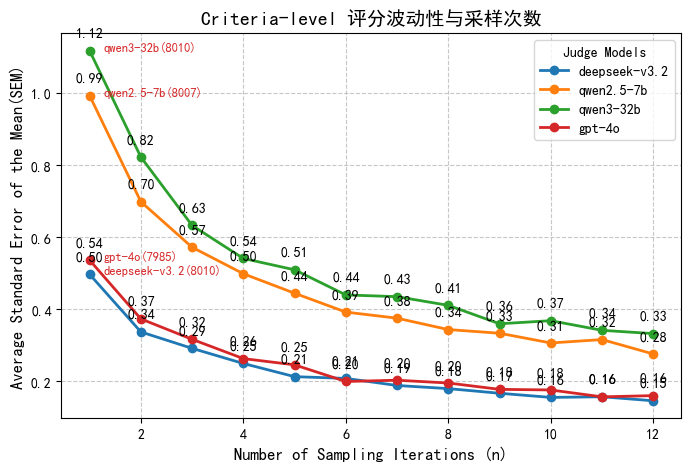

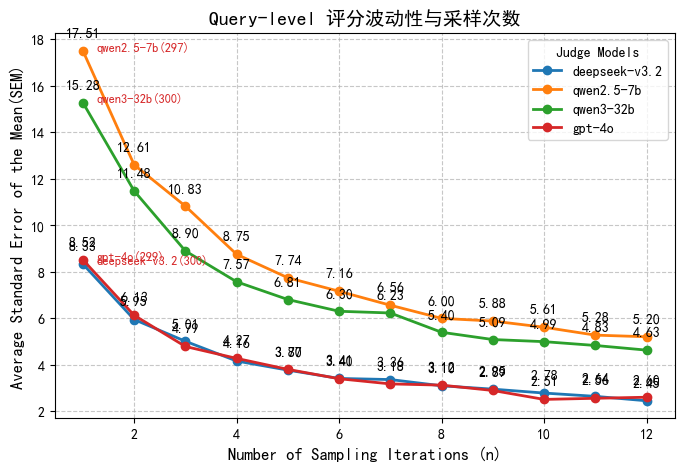

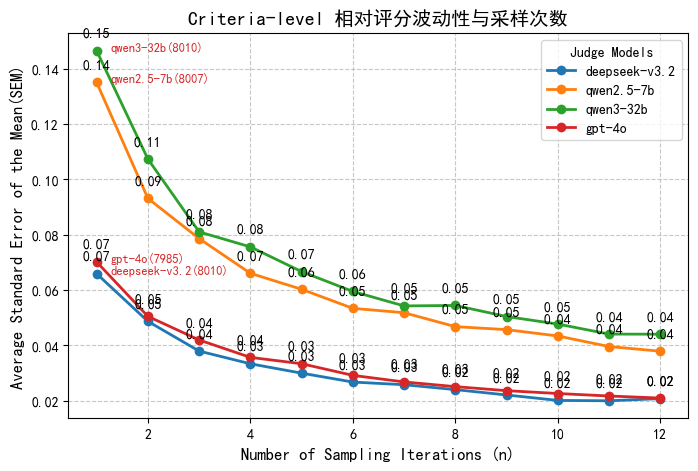

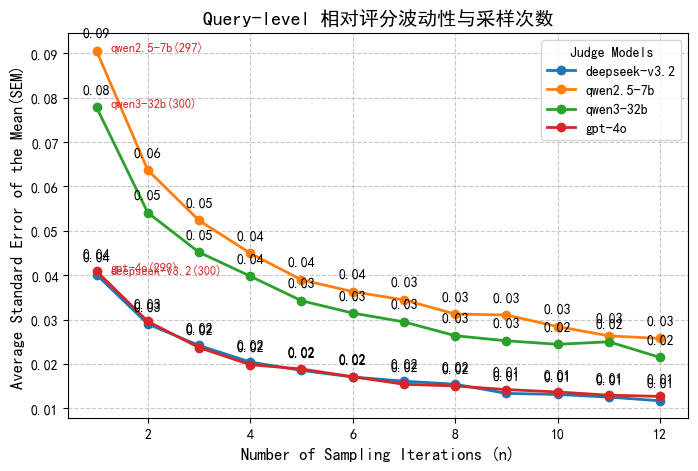

In [61]:
plot_figure(n_vals, sems_rubr, title="Criteria-level 评分波动性与采样次数", num = rubric_scores_matrix_combined)
plot_figure(n_vals, sems_conv, title="Query-level 评分波动性与采样次数", num = conversation_scores_matrix_combined)
plot_figure(n_vals, sems_rubr_normalized, title="Criteria-level 相对评分波动性与采样次数", num = rubric_scores_matrix_combined)
plot_figure(n_vals, sems_conv_normalized, title="Query-level 相对评分波动性与采样次数", num = conversation_scores_matrix_combined)
# 将上面四个图作为子图展示在同一张图中，方便对比

#### case study
1. 不同Judge相对SEM最大item及其共性
2. Item级相对 SEM 大小与 Response Model 相关性

In [31]:
import pandas as pd
import numpy as np

def extract_case_study_data(data, first_100, gen_models, judge_models):
    records =[]
    
    for gen_mod in gen_models:
        for judge_mod in judge_models:
            for i in data.keys():
                trials = data[i][gen_mod][judge_mod]
                rubrics = first_100[int(i)]['Rubrics']
                num_rubrics = len(rubrics)
                
                for k in range(num_rubrics):
                    scores =[]
                    for j in range(len(trials)):
                        if len(trials[j]) < num_rubrics:
                            continue
                        scores.append(_extract_score(trials[j][k]))
                    
                    # 过滤并保留12次有效采样
                    valid_scores =[s for s in scores if not np.isnan(s)]
                    if len(valid_scores) >= 12:
                        final_12_scores = valid_scores[:12]
                        points = rubrics[k]['points']
                        
                        # 计算该item的波动（单次采样的SEM近似为样本标准差）
                        std = np.std(final_12_scores, ddof=1)
                        rel_std = std / points if points > 0 else 0
                        
                        records.append({
                            'judge_model': judge_mod,
                            'gen_model': gen_mod,
                            'dialog_id': i,
                            'rubric_idx': k,
                            'points': points,
                            'rubric_list_len': num_rubrics,
                            'std': std, # 绝对SEM
                            'rel_std': rel_std, # 相对SEM
                            'mean_score': np.mean(final_12_scores)
                        })
                        
    return pd.DataFrame(records)

# 生成DataFrame
df_case_study = extract_case_study_data(result, first_100, gen_models, judge_models)

In [34]:
def analyze_top_unstable_items(df, top_k=20):
    print("="*50)
    print("实验1：各Judge模型最不稳定的Item分析")
    print("="*50)
    
    for judge in df['judge_model'].unique():
        print(f"\n>>> Judge Model: {judge}")
        df_judge = df[df['judge_model'] == judge]
        
        # 按相对SEM降序排列，取前 top_k
        top_unstable = df_judge.sort_values(by='rel_std', ascending=False).head(top_k)
        
        # 统计这批不稳定 item 的 rubric_list 长度
        avg_len_top = top_unstable['rubric_list_len'].mean()
        avg_len_all = df_judge['rubric_list_len'].mean()
        
        print(f"Top {top_k} 不稳定 Item 的平均 rubric-list 长度: {avg_len_top:.2f}")
        print(f"该 Judge 所有 Item 的平均 rubric-list 长度: {avg_len_all:.2f}")
        
        if avg_len_top > avg_len_all:
            print("-> 结论线索：不稳定的评分点似乎集中在 rubric 数量较多的复杂对话中（上下文过长或任务过重）。")
        else:
            print("-> 结论线索：不稳定评分点与 rubric_list 长度无明显正相关。")
            
        print(f"\nTop 5 具体最不稳定 Item 案例:")
        for idx, row in top_unstable.head(5).iterrows():
            print(f"  Dialog: {row['dialog_id']}, Gen Model: {row['gen_model']}")
            print(f"  Rubric 长度: {row['rubric_list_len']}, 满分: {row['points']}, 均分: {row['mean_score']:.2f}")
            print(f"  Relative SEM: {row['rel_std']:.4f} (Absolute SEM: {row['std']:.4f})")
            print("-"*30)
            # 打印rubric文本，你可以人工观察是否这类rubric具有“主观性强”、“标准模糊”、“长文本推理”等共性
            # todo

analyze_top_unstable_items(df_case_study)

实验1：各Judge模型最不稳定的Item分析

>>> Judge Model: deepseek-v3.2
Top 20 不稳定 Item 的平均 rubric-list 长度: 28.30
该 Judge 所有 Item 的平均 rubric-list 长度: 28.39
-> 结论线索：不稳定评分点与 rubric_list 长度无明显正相关。

Top 5 具体最不稳定 Item 案例:
  Dialog: 58, Gen Model: gpt-oss-120b
  Rubric 长度: 28, 满分: 7, 均分: 3.50
  Relative SEM: 0.5222 (Absolute SEM: 3.6556)
------------------------------
  Dialog: 1, Gen Model: qwen2.5-72b
  Rubric 长度: 30, 满分: 4, 均分: 2.00
  Relative SEM: 0.5222 (Absolute SEM: 2.0889)
------------------------------
  Dialog: 18, Gen Model: qwen2.5-72b
  Rubric 长度: 32, 满分: 10, 均分: 5.00
  Relative SEM: 0.5222 (Absolute SEM: 5.2223)
------------------------------
  Dialog: 24, Gen Model: qwen3-235b
  Rubric 长度: 35, 满分: 8, 均分: 4.00
  Relative SEM: 0.5222 (Absolute SEM: 4.1779)
------------------------------
  Dialog: 52, Gen Model: gpt-oss-120b
  Rubric 长度: 20, 满分: 9, 均分: 4.50
  Relative SEM: 0.5222 (Absolute SEM: 4.7001)
------------------------------

>>> Judge Model: qwen2.5-7b
Top 20 不稳定 Item 的平均 rubric-list 长度

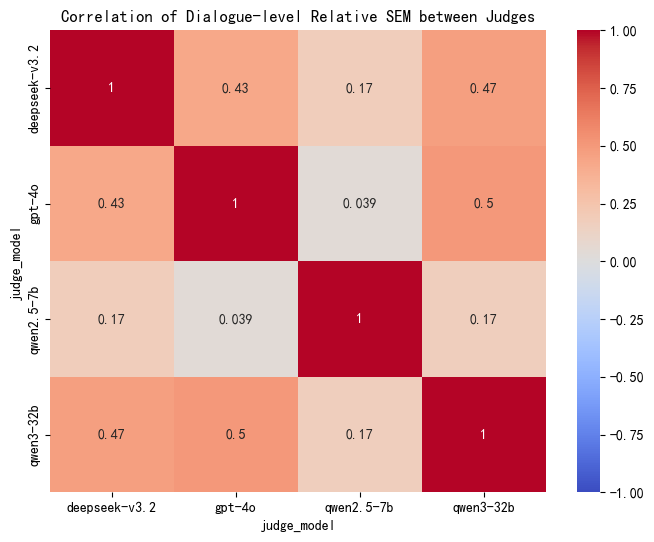

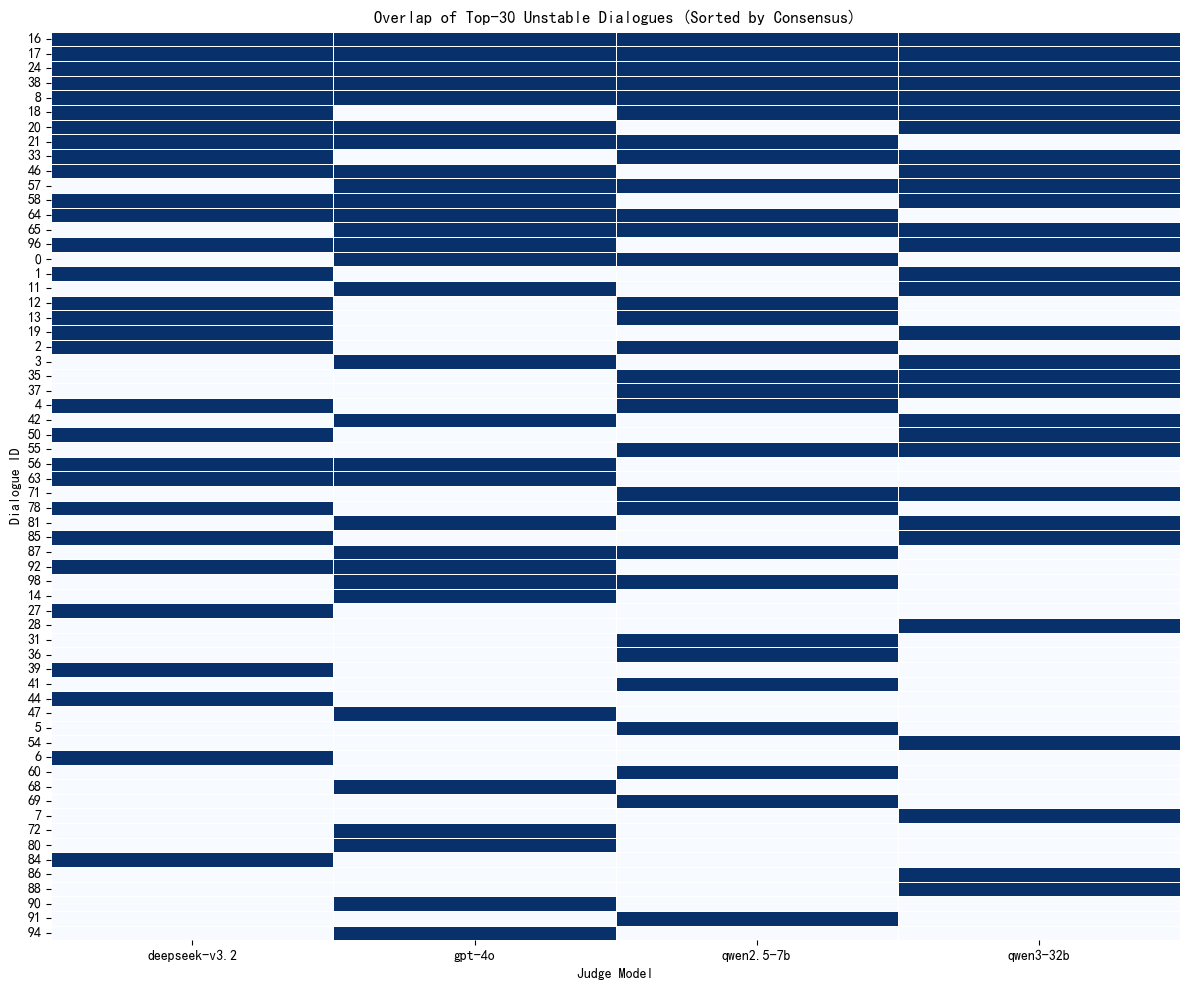

In [43]:
# 将数据聚合成 dialogue 级别 (对每个 dialogue + judge_model 的所有 rubric 取平均)
dialogue_df = df_case_study.groupby(['dialog_id', 'judge_model']).agg({
    'std': 'mean',        # 该对话的平均绝对 SEM
    'rel_std': 'mean',    # 该对话的平均相对 SEM
    'rubric_list_len': 'first'
}).reset_index()
# 将数据重塑为 [dialog_id] 为索引，[judge_model] 为列的矩阵
pivot_rel_sem = dialogue_df.pivot(index='dialog_id', columns='judge_model', values='rel_std')

# 计算 Judge 之间在“不稳定程度”上的相关性
corr_matrix = pivot_rel_sem.corr(method='spearman') # 使用斯皮尔曼，只关注排序一致性

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation of Dialogue-level Relative SEM between Judges")
plt.show()
def plot_top_n_overlap_fixed(pivot_df, n=30):
    # 1. 找出每个 judge 前 n 个最不稳定的对话
    top_n_sets = {judge: set(pivot_df[judge].nlargest(n).index) for judge in pivot_df.columns}
    
    # 2. 创建二进制 DataFrame
    binary_df = pd.DataFrame(0, index=pivot_df.index, columns=pivot_df.columns)
    for judge, ids in top_n_sets.items():
        binary_df.loc[list(ids), judge] = 1
        
    # 3. 筛选出至少在一个 Judge 中属于 Top-N 的对话
    plot_df = binary_df[binary_df.sum(axis=1) > 0].copy()
    
    # --- 关键修改：自定义排序逻辑 ---
    # 按照“被选中的次数”降序排列，次数相同则按 Dialog ID 数值升序排列
    plot_df['count'] = plot_df.sum(axis=1)
    plot_df = plot_df.sort_values(by=['count', 'dialog_id'], ascending=[False, True])
    plot_df = plot_df.drop(columns=['count'])
    # -------------------------------
        
    plt.figure(figsize=(12, 10))
    sns.heatmap(plot_df, cmap="Blues", cbar=False, 
                yticklabels=True, linewidths=0.5, linecolor='white')
    
    plt.title(f"Overlap of Top-{n} Unstable Dialogues (Sorted by Consensus)")
    plt.xlabel("Judge Model")
    plt.ylabel("Dialogue ID")
    plt.tight_layout()
    plt.show()

# 调用函数（前提：pivot_df 的 index 应该是数字类型的 dialog_id）
# 如果 index 是字符串，先转一下：pivot_rel_sem.index = pivot_rel_sem.index.astype(int)
plot_top_n_overlap_fixed(pivot_rel_sem, n=30)

In [52]:
# print 0th dialogue in dialogue_df
print("Dialog ID 0 的 Prompt:{}".format(dialogue_df.iloc[0]))

Dialog ID 0 的 Prompt:dialog_id                      0
judge_model        deepseek-v3.2
std                      0.36775
rel_std                 0.047964
rubric_list_len               20
Name: 0, dtype: object


In [53]:
# 查看第16个dialog的问题
# 从first_100中找到dialog_id为16的对话 
unstable_dialogs = [16,17,24,38]
for dialog_id in unstable_dialogs:
    dialog_16 = first_100[int(dialog_id)]
    print("Dialog ID {} 的 Prompt:{}".format(dialog_id, dialog_16['prompt'][0]['content']))

Dialog ID 16 的 Prompt:Firma, w której pracuję (branża IT - programowanie, moja pierwsza praca) zakazała mi pracy zdalnej z powodu "za niskiej wydajności" i zmusiła do przychodzenia do biura. Wszyscy inni, włącznie z nowo zatrudnianymi, mają możliwość wyboru miejsca pracy i większość dalej pracuje z domu, jak podczas pandemii.

Nie zgadzam się z tym, że pracowałem za wolno, uważam że robiłem wszystko dobrze. Czy są jakieś zewnętrzne instytucje, jako że w samej firmie zrobiłem już chyba wszystko co mogłem i nie udało mi się przekonać do zmiany zdania, które by mi pomogły?

Dodam, że w umowie nic o pracy zdalnej nie ma, chociaż zacząłem pracę na początku pandemii i z wyjątkiem tych ostatnich kilku miesięcy pracowałem tylko zdalnie. Wszyscy oprócz mnie, z tego co wiem, dostali jakieś aneksy dotyczące pracy zdalnej w tym roku, ja nie.

Jeżeli nie można zrobić absolutnie nic, chciałbym żeby firma całkowicie mnie zwolniła, najlepiej bez okresu wypowiedzenia, tak żebym znalazł sobie inną pracę


实验2：生成模型 (gen_model) 对评估稳定性的影响


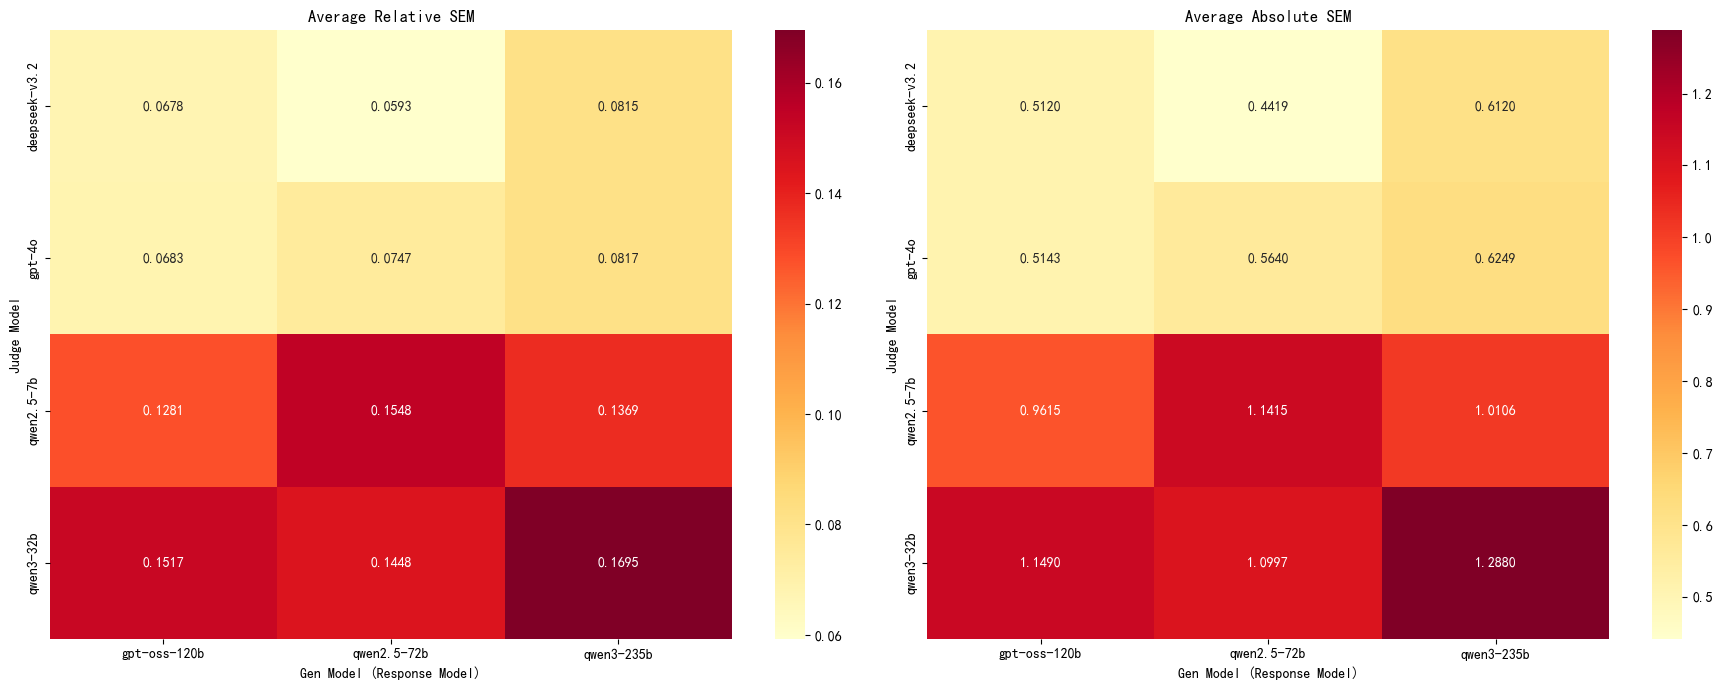


-> 结论线索：
观察热力图或表格的列（Gen Model）：
如果某一列的值普遍偏高，说明这个 Gen Model 生成的回复非常容易让所有的 Judge 模型产生分歧（可能是因为它生成的回复处于'边界状态'，似是而非，或者排版极其混乱导致解析器时好时坏）。
如果某一行中，不同列的值差异巨大，说明该 Judge 模型的稳定性严重依赖于它在评估谁。


In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_impact_of_gen_model(df):
    print("\n" + "="*50)
    print("实验2：生成模型 (gen_model) 对评估稳定性的影响")
    print("="*50)
    
    # 使用 Pandas Pivot Table 创建交叉表
    # 计算每个 Judge 对每个 Gen Model 评分时的平均相对 SEM
    pivot_rel_std = df.pivot_table(
        index='judge_model', 
        columns='gen_model', 
        values='rel_std', 
        aggfunc='mean'
    )
    pivot_std = df.pivot_table(
        index='judge_model', 
        columns='gen_model', 
        values='std', 
        aggfunc='mean'
    )
    
    # ---------------- 可视化热力图：合并为两个子图 ----------------
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # 第一个子图：相对 SEM (Relative SEM)
    sns.heatmap(pivot_rel_std, annot=True, cmap="YlOrRd", fmt=".4f", 
                ax=axes[0], vmax=pivot_rel_std.max().max(), cbar=True)
    axes[0].set_title("Average Relative SEM")
    axes[0].set_ylabel("Judge Model")
    axes[0].set_xlabel("Gen Model (Response Model)")

    # 第二个子图：绝对 SEM (Absolute SEM)
    sns.heatmap(pivot_std, annot=True, cmap="YlOrRd", fmt=".4f", 
                ax=axes[1], vmax=pivot_std.max().max(), cbar=True)
    axes[1].set_title("Average Absolute SEM")
    axes[1].set_ylabel("Judge Model")
    axes[1].set_xlabel("Gen Model (Response Model)")

    plt.tight_layout()
    plt.savefig("gen_model_impact_heatmaps_combined.png", dpi=300)
    plt.show()
    
    print("\n-> 结论线索：")
    print("观察热力图或表格的列（Gen Model）：")
    print("如果某一列的值普遍偏高，说明这个 Gen Model 生成的回复非常容易让所有的 Judge 模型产生分歧（可能是因为它生成的回复处于'边界状态'，似是而非，或者排版极其混乱导致解析器时好时坏）。")
    print("如果某一行中，不同列的值差异巨大，说明该 Judge 模型的稳定性严重依赖于它在评估谁。")

analyze_impact_of_gen_model(df_case_study)

### 3.2 重复采样对一致性的提升

#### 3.2.1 加载 Judge 的 Ground-Truth

`ground_truth[i][gen][j]`:第`i`条对话，`gen`生成的回答，第`j`条rubric的评测结果

In [14]:
# 加载ground_truth
# ground_truth[i][gen][j]:第i条对话，gen生成的回答，第j条rubric的评测结果
ground_truth = json.load(open("ground_truth.json", "r", encoding='utf-8'))

In [15]:
import numpy as np
import scipy.stats
import warnings
from collections import defaultdict

# 目标：计算特定 [gen_model][judge_model] 对在不同采样次数(1~12)下的 Spearman 相关系数
# 返回：1. rubric_spearman_matrix: shape [Valid_Conversations, 12]，对话内部(Rubric级别)的 Spearman 相关系数
#      2. conv_spearman_array: shape [12]，跨对话(全局总分级别)的 Spearman 相关系数
def get_spearman(data, gen_model, judge_model, B=50):
    
    valid_trials_list =[] # 存储每个对话的前12次有效采样矩阵
    gt_rubric_scores =[]  # 存储每个对话的 Ground Truth (Rubric级得分列表)
    gt_conv_scores =[]    # 存储每个对话的 Ground Truth (对话归一化总分)
    max_scores_list =[]   # 存储每个对话的满分 (所有rubric的points之和)
    
    # 1. 提取与清洗数据
    for i in data.keys():
        trials = data[i][gen_model][judge_model]
        num_rubrics = len(first_100[int(i)]['Rubrics'])
        max_score = sum(rubric['points'] for rubric in first_100[int(i)]['Rubrics'])
        
        valid_trial_scores =[] # 存储当前对话中，每一次合法的采样 (包含所有rubric的得分)
        
        # 遍历该对话的每一次采样
        for trial in trials: 
            if len(trial) < num_rubrics:  # 如果该次采样的评分点数量不足，说明数据不完整，直接跳过该采样
                continue
                
            trial_scores =[]
            # 遍历该次采样下的所有评分点 k
            for k in range(num_rubrics):
                trial_scores.append(_extract_score(trial[k])) # 如果数据异常会返回 NaN
                    
            if not np.any(np.isnan(trial_scores)): # 只有当该次采样的所有评分点都有效时，才保留该采样
                valid_trial_scores.append(trial_scores)
        
        # 仅保留拥有至少 12 次完整合法采样的对话
        if len(valid_trial_scores) >= 12:
            # 截取前12次，并转为 Shape: [12, num_rubrics] 的 NumPy 数组
            valid_trials_list.append(np.array(valid_trial_scores[:12]))
            
            # 提取对应的 Ground Truth 数据
            gt_score = [s['score'] for s in ground_truth[i][gen_model]]
            gt_rubric_scores.append(np.array(gt_score)) # Shape: [num_rubrics]
            gt_conv_scores.append(sum(gt_score) / max_score) # 归一化总分
            max_scores_list.append(max_score)
        else:
            print(f"对话 {i} 因合法完整采样仅有 {len(valid_trial_scores)} 次(需12次)，已被整体剔除")

    m = len(valid_trials_list)
    
    # 全局总分不受 rubrics 数量影响，转为全局 1D 数组，Shape: [m]
    gt_conv_scores = np.array(gt_conv_scores)         
    max_scores_list = np.array(max_scores_list)       
    
    # 计算 Spearman 相关系数的结果矩阵
    rubric_spearman_matrix = np.zeros((m, 12)) # 对应原 rubric_spearman_data
    conv_spearman_array = np.zeros(12)         # 对应原 conv_spearman_data

    with warnings.catch_warnings():
        warnings.simplefilter("ignore") # 忽略方差为0产生的 Spearman NaN 警告
        
        # 2. 核心重采样逻辑 (j 为采样次数，从 1 到 12)
        for j in range(1, 13):
            b_rubric_spearman = np.zeros((B, m)) # 存储 B 次 bootstrap 的 Rubric 级 Spearman
            b_conv_spearman = np.zeros(B)        # 存储 B 次 bootstrap 的 对话 级 Spearman
            
            for b in range(B):
                b_total_scores = np.zeros(m) # 存储当前 bootstrap 下，各个对话的归一化总分
                idx = np.random.randint(0, 12, size=j) # 独立随机有放回抽取 j 次，idx Shape: [j]=
                for i in range(m):
                    # 提取该对话 j 次采样的分数并按列求平均，返回 Shape: [num_rubrics]
                    sampled_avg = valid_trials_list[i][idx].mean(axis=0)
                    
                    # --- 计算对话内部，Rubric 级别的 Spearman ---
                    rho_rubric, _ = scipy.stats.spearmanr(sampled_avg, gt_rubric_scores[i])
                    b_rubric_spearman[b, i] = rho_rubric
                    
                    # 累加当前抽样对话的总分，并归一化
                    b_total_scores[i] = sampled_avg.sum() / max_scores_list[i]
                
                # --- 计算跨对话，全局总分级别的 Spearman ---
                rho_conv, _ = scipy.stats.spearmanr(b_total_scores, gt_conv_scores)
                b_conv_spearman[b] = rho_conv
            
            # 记录 B 次实验的均值 (忽略由于方差为 0 导致的 NaN)
            rubric_spearman_matrix[:, j-1] = np.nanmean(b_rubric_spearman, axis=0)
            conv_spearman_array[j-1] = np.nanmean(b_conv_spearman)

    return rubric_spearman_matrix, conv_spearman_array


# ================== 外部主调用逻辑 ==================

rubric_spearman_dict = defaultdict(dict) # 存储 Rubric 级 Spearman
conv_spearman_dict = defaultdict(dict)   # 存储 对话 级 Spearman

# 1. 提取 result
for gen_mod in gen_models:
    for judge_mod in judge_models:
        rubric_spearman_dict[gen_mod][judge_mod], conv_spearman_dict[gen_mod][judge_mod] = \
            get_spearman(result, gen_mod, judge_mod)

# 2. 按 judge_model 合并 gen_model 的结果
avg_rubric_spearman = {}
avg_conv_spearman = {}

for judge_mod in judge_models:
    # 过滤空数据并提取矩阵
    rubric_list = [rubric_spearman_dict[g][judge_mod] for g in gen_models]
    conv_list = [conv_spearman_dict[g][judge_mod] for g in gen_models]
    
    # np.vstack 将 rubric_list 从 [m, 12] 纵向堆叠为[m * 参与计算的gen_models数量, 12]
    avg_rubric_spearman[judge_mod] = np.nanmean(np.vstack(rubric_list), axis=0)
    # np.vstack 将 conv_list 从 [12] 堆叠为[参与计算的gen_models数量, 12] 
    avg_conv_spearman[judge_mod] = np.nanmean(np.vstack(conv_list), axis=0)

对话 10 因合法完整采样仅有 8 次(需12次)，已被整体剔除
对话 47 因合法完整采样仅有 6 次(需12次)，已被整体剔除
对话 85 因合法完整采样仅有 6 次(需12次)，已被整体剔除
对话 38 因合法完整采样仅有 0 次(需12次)，已被整体剔除


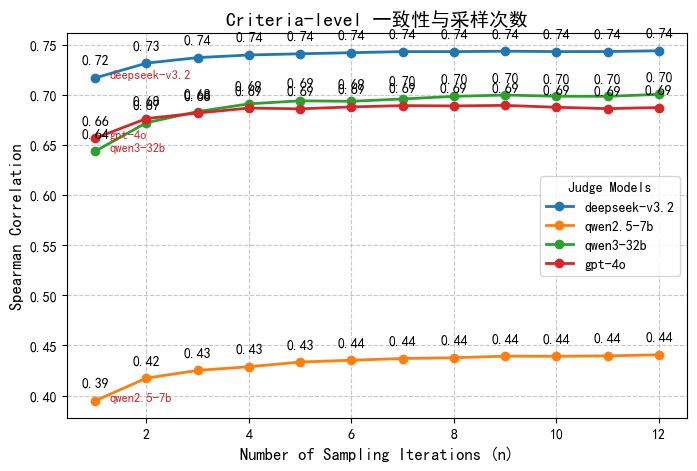

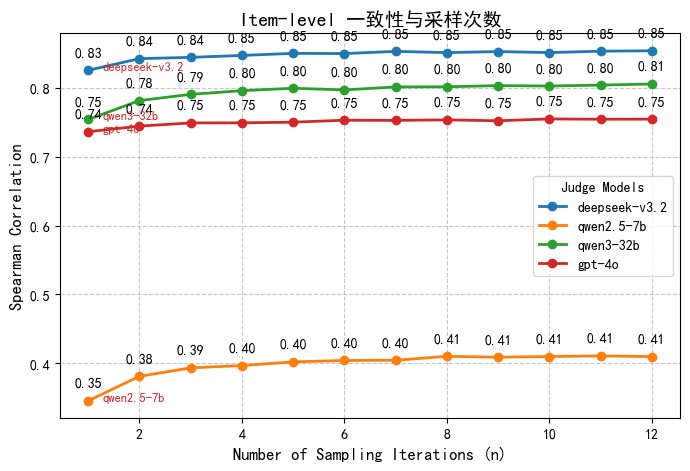

In [62]:
plot_figure(n_vals, avg_rubric_spearman, title="Criteria-level 一致性与采样次数", ylabel='Spearman Correlation')
plot_figure(n_vals, avg_conv_spearman, title="Item-level 一致性与采样次数", ylabel='Spearman Correlation')

### 3.3 输入敏感性实验
+ 4种prompt：`翻译成英文`，`翻译成西班牙语`，`deepseek v3.2改写`，`qwen2.5 7b改写`

In [16]:
result2 = json.load(open("exp2_result.json", "r", encoding='utf-8'))

In [25]:
print(result2['0']['gpt-oss-120b'].keys()) # 打印第一条对话的 gen_model 列表，检查数据结构
# result2[i][gen][judge][variant][j][k]
# 第i条对话，gen生成的回答，judge评测的原始分数, prompt进行variant的变体评测，第j次采样，第k个rubric的得分
for gen_model in result2['0'].keys():
    for judge_model in result2['0'][gen_model].keys():
        print(f"对话 0 的 gen_model: {gen_model}, judge_model: {judge_model}")

dict_keys(['qwen3-32b'])
对话 0 的 gen_model: qwen2.5-72b, judge_model: qwen3-32b
对话 0 的 gen_model: gpt-oss-120b, judge_model: qwen3-32b
对话 0 的 gen_model: qwen3-235b, judge_model: qwen3-32b


#### 3.3.1 多prompt的结果混合后，重采样对鲁棒性的影响

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict

gen_models = ['qwen2.5-72b', 'gpt-oss-120b', 'qwen3-235b']
judge_models = ['qwen3-32b']
# 设定阈值：20次采样（5个variant * 4次）中，至少需要多少次有效数据才保留该条目
TOTAL_SAMPLES = 20
MIN_VALID_SAMPLES = 16 

# 目标：提取出所有对话rubric级的某一个 [gen_model][judge_model] 对的评分矩阵
def extract_valid_scores_v2(data, gen_model, judge_model):
    
    valid_rubric_data = [] 
    rubric_total_scores =[] 
    
    for i in data.keys():
        
        # 1. 将 variant 层级展平，组合成 20 次 trials
        variants_dict = data[i][gen_model][judge_model]
        trials =[]
        for variant_name, samplings in variants_dict.items():
            for sample in samplings:
                trials.append(sample)
                
        num_rubrics = len(first_100[int(i)]['Rubrics']) 

        for k in range(num_rubrics):
            scores =[]
            for j in range(len(trials)): # 遍历 20 次采样

                # 如果第j次采样rubric-list长度不足，跳过
                if len(trials[j]) < num_rubrics:
                    continue
                scores.append(_extract_score(trials[j][k])) # 使用之前定义的辅助函数统一解析评分点得分

            # 只有当该评分点在 20 次采样中达到 MIN_VALID_SAMPLES 次都有值，才参与后续计算
            if np.sum(~np.isnan(scores)) >= MIN_VALID_SAMPLES: 
                scores = [s for s in scores if not np.isnan(s)]
                valid_rubric_data.append(scores[:MIN_VALID_SAMPLES]) # 截断对齐
                rubric_total_scores.append(first_100[int(i)]['Rubrics'][k]['points']) 
                
    return np.array(valid_rubric_data), np.array(rubric_total_scores)


# 目标：提取对话级别的总分矩阵
def extract_conversation_scores_v2(data, gen_model, judge_model):

    valid_conv_data =[] 
    conversation_total_scores =[]

    for i in data.keys():
        
        # 1. 将 variant 层级展平
        variants_dict = data[i][gen_model][judge_model]
        trials =[]
        for variant_name, samplings in variants_dict.items():
            for sample in samplings:
                trials.append(sample)
                
        num_rubrics = len(first_100[int(i)]['Rubrics']) 
        valid_samplings_scores =[] 
        
        for j in range(len(trials)):
            if len(trials[j]) < num_rubrics:
                continue
            
            sampling_total_score = 0.0 

            for k in range(num_rubrics):
                sampling_total_score += _extract_score(trials[j][k])
            
            if sampling_total_score is not np.nan:
                valid_samplings_scores.append(sampling_total_score)

        # 满足最小合法采样次数才保留
        if len(valid_samplings_scores) >= MIN_VALID_SAMPLES:
            valid_conv_data.append(valid_samplings_scores[:MIN_VALID_SAMPLES]) 
            conversation_total_scores.append(sum([item['points'] for item in first_100[int(i)]['Rubrics']])) 
                
    return np.array(valid_conv_data), np.array(conversation_total_scores)


# ================= 数据提取主流程 =================

rubric_scores_matrix_v2 = defaultdict(dict) 
rubric_total_score_matrix_v2 = defaultdict(dict) 
conversation_scores_matrix_v2 = defaultdict(dict) 
conversation_total_scores_matrix_v2 = defaultdict(dict) 

for gen_mod in gen_models:
    for judge_mod in judge_models:
        # 注意这里传入的是 result2
        rubric_scores_matrix_v2[gen_mod][judge_mod], rubric_total_score_matrix_v2[gen_mod][judge_mod] = \
            extract_valid_scores_v2(result2, gen_mod, judge_mod)
        
        conversation_scores_matrix_v2[gen_mod][judge_mod], conversation_total_scores_matrix_v2[gen_mod][judge_mod] = \
            extract_conversation_scores_v2(result2, gen_mod, judge_mod)

In [19]:
# ================= 合并矩阵 =================

rubric_scores_matrix_combined_v2 = {}
rubric_total_score_matrix_combined_v2 = {}
conversation_scores_matrix_combined_v2 = {}
conversation_total_scores_matrix_combined_v2 = {}

for judge_mod in judge_models:
    combined_rubr =[]
    combined_conv = []
    combined_rubr_totals = []
    combined_conv_totals =[]
    
    for gen_mod in gen_models:
        combined_rubr.append(rubric_scores_matrix_v2[gen_mod][judge_mod])
        combined_rubr_totals.append(rubric_total_score_matrix_v2[gen_mod][judge_mod])
        
        combined_conv.append(conversation_scores_matrix_v2[gen_mod][judge_mod])
        combined_conv_totals.append(conversation_total_scores_matrix_v2[gen_mod][judge_mod])
            
    rubric_scores_matrix_combined_v2[judge_mod] = np.concatenate(combined_rubr, axis=0)
    rubric_total_score_matrix_combined_v2[judge_mod] = np.concatenate(combined_rubr_totals, axis=0)

    conversation_scores_matrix_combined_v2[judge_mod] = np.concatenate(combined_conv, axis=0)
    conversation_total_scores_matrix_combined_v2[judge_mod] = np.concatenate(combined_conv_totals, axis=0)
# 打印维度检查
for judge_mod in judge_models:
    print(f"{judge_mod} 评分矩阵: {rubric_scores_matrix_combined_v2[judge_mod].shape}, 总分: {rubric_total_score_matrix_combined_v2[judge_mod].shape}")
    print(f"{judge_mod} 对话矩阵: {conversation_scores_matrix_combined_v2[judge_mod].shape}, 对话总分: {conversation_total_scores_matrix_combined_v2[judge_mod].shape}")
print("\n")

qwen3-32b 评分矩阵: (7762, 16), 总分: (7762,)
qwen3-32b 对话矩阵: (291, 16), 对话总分: (291,)




In [49]:
# ================= 计算稳定性 =================

# 优化后的 Bootstrap 计算，自动适配样本维度而不是硬编码的 12

n_vals = range(1, MIN_VALID_SAMPLES + 1) 

sems_rubr_v2 = {}
sems_conv_v2 = {}
sems_rubr_normalized_v2 = {}
sems_conv_normalized_v2 = {}

for judge_mod in judge_models:
    if rubric_scores_matrix_combined_v2[judge_mod].size > 0:
        sems_rubr_v2[judge_mod] = calculate_stability(rubric_scores_matrix_combined_v2[judge_mod], n_vals)
        sems_conv_v2[judge_mod] = calculate_stability(conversation_scores_matrix_combined_v2[judge_mod], n_vals)
        
        sems_rubr_normalized_v2[judge_mod] = calculate_stability(
            rubric_scores_matrix_combined_v2[judge_mod], n_vals, normalized=True, total_scores=rubric_total_score_matrix_combined_v2[judge_mod])
        sems_conv_normalized_v2[judge_mod] = calculate_stability(
            conversation_scores_matrix_combined_v2[judge_mod], n_vals, normalized=True, total_scores=conversation_total_scores_matrix_combined_v2[judge_mod])

# 写入文件
json.dump(sems_rubr_v2, open("stability_results_v2.json", "w", encoding='utf-8'), ensure_ascii=False, indent=4)
json.dump(sems_conv_v2, open("stability_results_conversation_v2.json", "w", encoding='utf-8'), ensure_ascii=False, indent=4)

C:\Users\Zhouxj's Lenovo\AppData\Local\Temp\ipykernel_8716\1151264426.py:24: RuntimeWarning: Mean of empty slice
  bootstrap_means[:, b] = np.nanmean(subset, axis=1)


In [53]:
n_vals = range(1,13)

In [50]:
# sems_rubr_v2中只有一个judge_model的结果，将key改为'qwen3-32b-v2'，以示区分
# 在合并sems_rubr['qwen3-32b']和sems_rubr_v2['qwen3-32b']时，使用sems_rubr_v2['qwen3-32b-v2']来代表v2版本的结果
sems_rubr_v2 = {'qwen3-32b-v2': sems_rubr_v2['qwen3-32b'][:12],'qwen3-32b': sems_rubr['qwen3-32b']}
sems_conv_v2 = {'qwen3-32b-v2': sems_conv_v2['qwen3-32b'][:12],'qwen3-32b': sems_conv['qwen3-32b']}
sems_rubr_normalized_v2 = {'qwen3-32b-v2':  sems_rubr_normalized_v2['qwen3-32b'][:12],'qwen3-32b': sems_rubr_normalized['qwen3-32b']}
sems_conv_normalized_v2 = {'qwen3-32b-v2': sems_conv_normalized_v2['qwen3-32b'][:12],'qwen3-32b': sems_conv_normalized['qwen3-32b']}

In [51]:
sems_rubr_v2

{'qwen3-32b-v2': [np.float64(1.2374509854636326),
  np.float64(0.891901128798938),
  np.float64(0.6963966414675303),
  np.float64(0.6323193579912221),
  np.float64(0.5292532715901698),
  np.float64(0.5042017722648309),
  np.float64(0.47805703705356223),
  np.float64(0.43532358972568863),
  np.float64(0.4122361511286433),
  np.float64(0.3955692624236762),
  np.float64(0.3979852596724495),
  np.float64(0.35656228881162294)],
 'qwen3-32b': [np.float64(1.1082073299320954),
  np.float64(0.7882179390255789),
  np.float64(0.626794620015354),
  np.float64(0.5628360077648727),
  np.float64(0.5010213467628468),
  np.float64(0.47033834731391844),
  np.float64(0.4117640565813582),
  np.float64(0.41423092311077303),
  np.float64(0.3774602906774156),
  np.float64(0.36130838935632104),
  np.float64(0.33116181620035207),
  np.float64(0.29606011942342014)]}

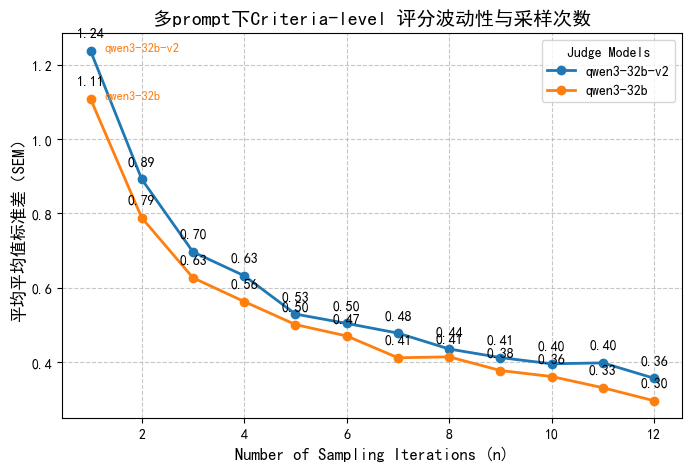

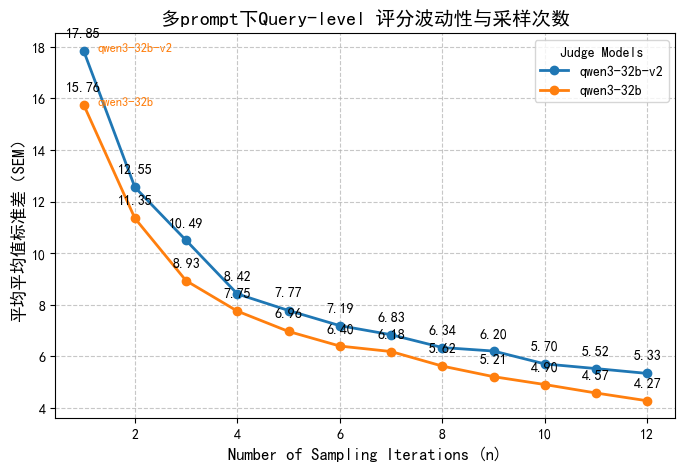

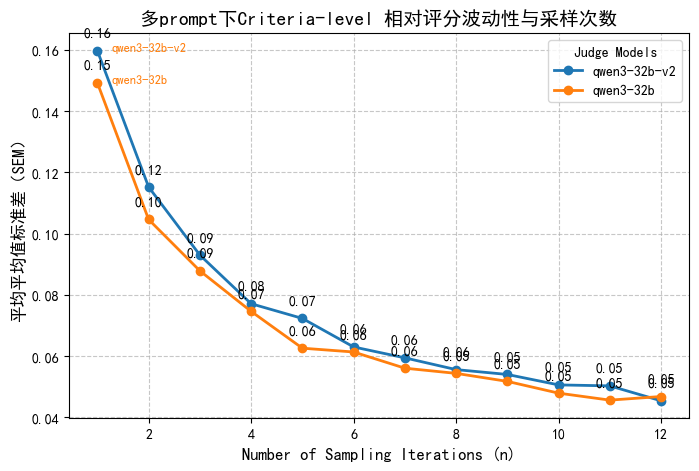

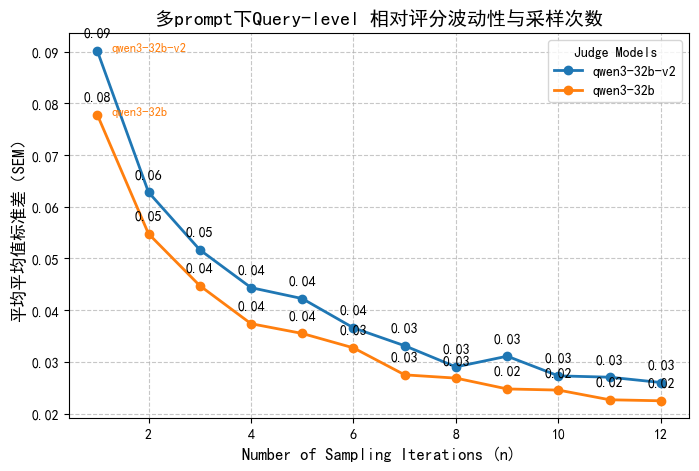

In [56]:
plot_figure(n_vals, sems_rubr_v2, title="多prompt下Criteria-level 评分波动性与采样次数",ylabel='平均平均值标准差（SEM）')
plot_figure(n_vals, sems_conv_v2, title="多prompt下Query-level 评分波动性与采样次数",ylabel='平均平均值标准差（SEM）')
plot_figure(n_vals, sems_rubr_normalized_v2, title="多prompt下Criteria-level 相对评分波动性与采样次数",ylabel='平均平均值标准差（SEM）')
plot_figure(n_vals, sems_conv_normalized_v2, title="多prompt下Query-level 相对评分波动性与采样次数",ylabel='平均平均值标准差（SEM）')

In [57]:
# ================== 外部主调用逻辑 ==================

rubric_spearman_dict_v2 = defaultdict(dict) # 存储 Rubric 级 Spearman
conv_spearman_dict_v2 = defaultdict(dict)   # 存储 对话 级 Spearman

# comb_result = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# 遍历原数据结构
comb_result = {}

for i in result2:
    comb_result[i] = {}
    for gen in result2[i]:
        comb_result[i][gen] = {}
        for judge in result2[i][gen]:
            comb_result[i][gen][judge] = []
            
            # 遍历所有 variant 和 j
            for variant in result2[i][gen][judge]:
                for j in range(len(result2[i][gen][judge][variant])):
                    rubrics_scores = result2[i][gen][judge][variant][j]
                    comb_result[i][gen][judge].append(rubrics_scores)


# 1. 提取 result
for gen_mod in gen_models:
    for judge_mod in judge_models:
        rubric_spearman_dict_v2[gen_mod][judge_mod], conv_spearman_dict_v2[gen_mod][judge_mod] = \
            get_spearman(comb_result, gen_mod, judge_mod)

# 2. 按 judge_model 合并 gen_model 的结果
avg_rubric_spearman_v2 = {}
avg_conv_spearman_v2 = {}

for judge_mod in judge_models:
    # 过滤空数据并提取矩阵
    rubric_list = [rubric_spearman_dict_v2[g][judge_mod] for g in gen_models]
    conv_list = [conv_spearman_dict_v2[g][judge_mod] for g in gen_models]
    
    # np.vstack 将 rubric_list 从 [m, 12] 纵向堆叠为[m * 参与计算的gen_models数量, 12]
    avg_rubric_spearman_v2[judge_mod] = np.nanmean(np.vstack(rubric_list), axis=0)
    # np.vstack 将 conv_list 从 [12] 堆叠为[参与计算的gen_models数量, 12] 
    avg_conv_spearman_v2[judge_mod] = np.nanmean(np.vstack(conv_list), axis=0)

对话 49 因合法完整采样仅有 8 次(需12次)，已被整体剔除


In [58]:
# 合并avg_rubric_spearman_v2[''qwen3-32b'']和avg_rubric_spearman['qwen3-32b']，使用avg_rubric_spearman_v2['qwen3-32b-v2']来代表v2版本的结果
avg_rubric_spearman_v2 = {'qwen3-32b-v2': avg_rubric_spearman_v2['qwen3-32b'][:12],'qwen3-32b': avg_rubric_spearman['qwen3-32b']}
avg_conv_spearman_v2 = {'qwen3-32b-v2': avg_conv_spearman_v2['qwen3-32b'][:12],'qwen3-32b': avg_conv_spearman['qwen3-32b']}

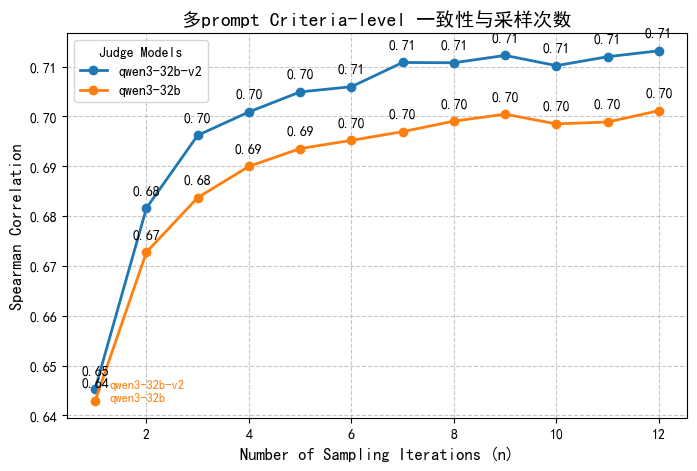

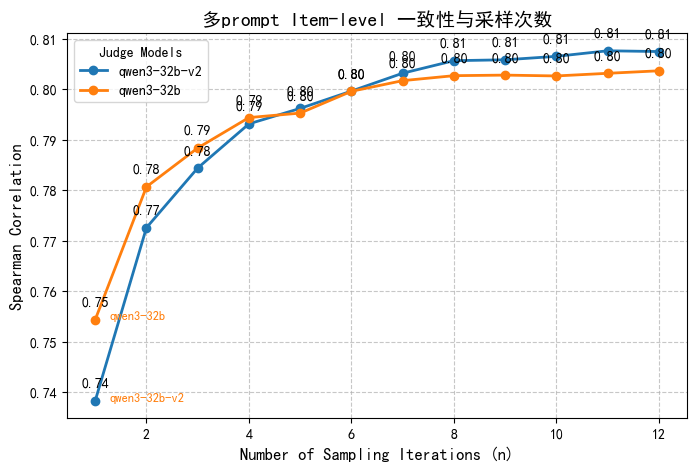

In [59]:
plot_figure(range(1,13), avg_rubric_spearman_v2, title="多prompt Criteria-level 一致性与采样次数", ylabel='Spearman Correlation')
plot_figure(range(1,13), avg_conv_spearman_v2, title="多prompt Item-level 一致性与采样次数", ylabel='Spearman Correlation')

### 3.4 增设实验：哪些因素会影响 Judge 的鲁棒性与和 Ground Truth 的一致性？

除了采样次数和 prompt variant 之外，这里进一步系统考察以下候选因素：

- `rubric-list` 长度：评分维度越多，Judge 是否越不稳定？
- 回答长度：更长或更短的回答，是否更容易引发评分波动？
- Ground Truth 的“中间态”程度：GT 越接近中间分数，是否意味着任务更模糊、更难评？
- 任务特征：格式约束、改写/翻译、代码、推理、事实性、安全性等任务标签，是否和稳定性/一致性有关？
- 回答生成模型：不同 Answer Model 生成的回答，是否系统性改变 Judge 的稳定性和校准程度？

这里同时考察四个指标：

- `mean_item_rel_sem`：item 级平均相对波动
- `conv_rel_sem`：query 总分级相对波动
- `rubric_alignment`：对话内部 rubric 排序与 GT 的 Spearman 一致性
- `abs_score_bias`：Judge 平均总分与 GT 总分的归一化偏差


In [53]:
import re
import pandas as pd
from scipy.stats import spearmanr

FACTOR_SEM_N = 12
FACTOR_BOOTSTRAP_B = 50

def _count_words(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r'\w+', text))

def _safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x = x[mask]
    y = y[mask]
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return spearmanr(x, y).statistic

def _bootstrap_sem_per_entry(scores_matrix, n=12, B=50):
    """?????????????????? bootstrap ??????????????"""
    scores_matrix = np.asarray(scores_matrix, dtype=float)
    if scores_matrix.ndim == 1:
        scores_matrix = scores_matrix.reshape(1, -1)

    sample_size = scores_matrix.shape[1]
    bootstrap_means = np.zeros((scores_matrix.shape[0], B))

    for b in range(B):
        indices = np.random.choice(sample_size, n, replace=True)
        bootstrap_means[:, b] = np.nanmean(scores_matrix[:, indices], axis=1)

    return np.nanstd(bootstrap_means, axis=1, ddof=1)

TASK_FLAG_PATTERNS = {
    'format_constraint': [
        r'json', r'format', r'table', r'bullet',
        r'word[s]?', r'character[s]?', r'sentence[s]?',
        r'list', r'yaml'
    ],
    'translation_or_rewrite': [
        r'translat', r'rewrite', r'paraphrase', r'summar', r'edit', r'polish'
    ],
    'code_or_tool': [
        r'code', r'python', r'sql', r'function',
        r'debug', r'program', r'script'
    ],
    'reasoning_math': [
        r'math', r'calculate', r'compute', r'solve', r'equation',
        r'proof', r'reason', r'analysis', r'analyze', r'explain why'
    ],
    'factual_grounding': [
        r'fact', r'accur', r'citation', r'cite', r'source',
        r'evidence', r'grounded', r'truthful'
    ],
    'safety_refusal': [
        r'safe', r'safety', r'harmful', r'dangerous', r'illegal',
        r'refuse', r'decline', r'policy'
    ]
}

PRIMARY_TASK_PRIORITY = [
    'translation_or_rewrite',
    'code_or_tool',
    'reasoning_math',
    'factual_grounding',
    'safety_refusal',
    'format_constraint'
]

def infer_task_flags(prompt, rubrics):
    rubric_text = ' '.join(item.get('description', '') for item in rubrics)
    text = f"{prompt}\n{rubric_text}".lower()
    flags = {name: any(re.search(pattern, text) for pattern in patterns)
             for name, patterns in TASK_FLAG_PATTERNS.items()}

    primary_task = 'other_general'
    for task_name in PRIMARY_TASK_PRIORITY:
        if flags[task_name]:
            primary_task = task_name
            break

    return flags, primary_task

def build_factor_dataframe(
    data,
    ground_truth,
    responses,
    first_100,
    gen_models,
    judge_models,
    min_valid_samples=12,
    sem_n=FACTOR_SEM_N,
    B=FACTOR_BOOTSTRAP_B,
):
    records = []

    for dialog_id in data.keys():
        dialog = first_100[int(dialog_id)]
        prompt = dialog['prompt'][0]['content']
        rubrics = dialog['Rubrics']
        rubric_points = np.array([item['points'] for item in rubrics], dtype=float)
        max_score = rubric_points.sum()
        flags, primary_task = infer_task_flags(prompt, rubrics)

        prompt_words = _count_words(prompt)
        prompt_chars = len(prompt)
        rubric_list_len = len(rubrics)

        for gen_model in gen_models:
            response_text = responses[int(dialog_id)][gen_model]
            response_words = _count_words(response_text)
            response_chars = len(response_text)

            gt_scores = np.array([_extract_score(item) for item in ground_truth[dialog_id][gen_model]], dtype=float)
            gt_norm_score = gt_scores.sum() / max_score if max_score > 0 else np.nan
            gt_midness = 1 - min(abs(gt_norm_score - 0.5) / 0.5, 1.0) if not np.isnan(gt_norm_score) else np.nan

            for judge_model in judge_models:
                trials = data[dialog_id][gen_model][judge_model]
                valid_trials = []

                for trial in trials:
                    if len(trial) < rubric_list_len:
                        continue
                    trial_scores = np.array([_extract_score(trial[k]) for k in range(rubric_list_len)], dtype=float)
                    if np.any(np.isnan(trial_scores)):
                        continue
                    valid_trials.append(trial_scores)

                if len(valid_trials) < min_valid_samples:
                    continue

                valid_trials = np.array(valid_trials[:min_valid_samples], dtype=float)
                item_sem = _bootstrap_sem_per_entry(valid_trials.T, n=sem_n, B=B)
                item_rel_sem = np.divide(
                    item_sem,
                    rubric_points,
                    out=np.full_like(item_sem, np.nan),
                    where=rubric_points > 0
                )

                conv_scores = valid_trials.sum(axis=1)
                conv_sem = _bootstrap_sem_per_entry(conv_scores, n=sem_n, B=B)[0]
                mean_scores = valid_trials.mean(axis=0)
                judge_norm_score = mean_scores.sum() / max_score if max_score > 0 else np.nan

                record = {
                    'dialog_id': int(dialog_id),
                    'gen_model': gen_model,
                    'judge_model': judge_model,
                    'prompt_words': prompt_words,
                    'prompt_chars': prompt_chars,
                    'response_words': response_words,
                    'response_chars': response_chars,
                    'rubric_list_len': rubric_list_len,
                    'total_points': max_score,
                    'gt_norm_score': gt_norm_score,
                    'gt_midness': gt_midness,
                    'mean_item_rel_sem': np.nanmean(item_rel_sem),
                    'conv_rel_sem': conv_sem / max_score if max_score > 0 else np.nan,
                    'rubric_alignment': _safe_spearman(mean_scores, gt_scores),
                    'abs_score_bias': abs(judge_norm_score - gt_norm_score),
                    'primary_task': primary_task
                }
                record.update(flags)
                records.append(record)

    return pd.DataFrame(records)

df_factors = build_factor_dataframe(
    result,
    ground_truth,
    responses,
    first_100,
    gen_models,
    judge_models,
    min_valid_samples=12
)

flag_cols = list(TASK_FLAG_PATTERNS.keys())
outcome_cols = ['mean_item_rel_sem', 'conv_rel_sem', 'rubric_alignment', 'abs_score_bias']

print(f'???????? (dialog, gen, judge) ???: {len(df_factors)}')
display(df_factors[outcome_cols + ['judge_model', 'gen_model', 'primary_task']].head())



???????? (dialog, gen, judge) ???: 300


,mean_item_rel_sem,conv_rel_sem,rubric_alignment,abs_score_bias,judge_model,gen_model,primary_task
0,0.038565,0.030979,0.307042,0.265251,qwen3-32b,qwen2.5-72b,translation_or_rewrite
1,0.040500,0.018496,0.343338,0.085512,qwen3-32b,gpt-oss-120b,translation_or_rewrite
2,0.049150,0.021239,0.054459,0.040850,qwen3-32b,qwen3-235b,translation_or_rewrite
3,0.039200,0.021689,0.285991,0.264074,qwen3-32b,qwen2.5-72b,other_general
4,0.090109,0.063525,NaN,0.309630,qwen3-32b,gpt-oss-120b,other_general


## 补充实验：打分上限与相对 SEM 的相关性

从因素分析里可以看出，不同样本的波动性存在系统差异。这里进一步直接回答一个更具体的问题：

- `query-level` 上，一个 query 的总满分越高，是否对应更大的相对 `SEM`？
- `criteria-level` 上，一个 rubric 的打分上限越高，是否对应更大的相对 `SEM`？

下面分别在 `query-level` 和 `criteria-level` 上，计算“打分上限”与相对 `SEM` 的 Spearman / Pearson 相关性，并给出散点图。


In [ ]:
def _safe_pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x = x[mask]
    y = y[mask]
    if len(x) < 2 or np.std(x) == 0 or np.std(y) == 0:
        return np.nan
    return np.corrcoef(x, y)[0, 1]

def build_score_sem_correlation_data(
    data,
    first_100,
    gen_models,
    judge_models,
    min_valid_samples=12,
    sem_n=FACTOR_SEM_N,
    B=FACTOR_BOOTSTRAP_B,
):
    query_records = []
    criteria_records = []

    for dialog_id in data.keys():
        dialog = first_100[int(dialog_id)]
        rubrics = dialog['Rubrics']
        rubric_points = np.array([item['points'] for item in rubrics], dtype=float)
        max_score = rubric_points.sum()
        rubric_list_len = len(rubrics)

        for gen_model in gen_models:
            for judge_model in judge_models:
                trials = data[dialog_id][gen_model][judge_model]
                valid_trials = []

                for trial in trials:
                    if len(trial) < rubric_list_len:
                        continue
                    trial_scores = np.array([_extract_score(trial[k]) for k in range(rubric_list_len)], dtype=float)
                    if np.any(np.isnan(trial_scores)):
                        continue
                    valid_trials.append(trial_scores)

                if len(valid_trials) < min_valid_samples:
                    continue

                valid_trials = np.array(valid_trials[:min_valid_samples], dtype=float)
                item_sem = _bootstrap_sem_per_entry(valid_trials.T, n=sem_n, B=B)
                item_rel_sem = np.divide(
                    item_sem,
                    rubric_points,
                    out=np.full_like(item_sem, np.nan),
                    where=rubric_points > 0
                )

                for rubric_idx in range(rubric_list_len):
                    max_points = rubric_points[rubric_idx]
                    criteria_records.append({
                        'dialog_id': int(dialog_id),
                        'gen_model': gen_model,
                        'judge_model': judge_model,
                        'rubric_idx': rubric_idx,
                        'rubric_points': max_points,
                        'rel_sem': item_rel_sem[rubric_idx],
                    })

                conv_scores = valid_trials.sum(axis=1)
                conv_sem = _bootstrap_sem_per_entry(conv_scores, n=sem_n, B=B)[0]
                query_records.append({
                    'dialog_id': int(dialog_id),
                    'gen_model': gen_model,
                    'judge_model': judge_model,
                    'query_total_points': max_score,
                    'rel_sem': conv_sem / max_score if max_score > 0 else np.nan,
                })

    return pd.DataFrame(query_records), pd.DataFrame(criteria_records)

def summarize_score_sem_correlations(df, level_name, score_sem_pairs):
    rows = []
    judge_groups = [('ALL', df)] + [
        (judge_name, df[df['judge_model'] == judge_name])
        for judge_name in sorted(df['judge_model'].unique())
    ]

    for judge_name, df_judge in judge_groups:
        for score_col, sem_col in score_sem_pairs:
            tmp = df_judge[[score_col, sem_col]].dropna()
            if len(tmp) < 8:
                continue
            rows.append({
                'level': level_name,
                'judge_model': judge_name,
                'score_col': score_col,
                'sem_col': sem_col,
                'spearman_rho': _safe_spearman(tmp[score_col].values, tmp[sem_col].values),
                'pearson_r': _safe_pearson(tmp[score_col].values, tmp[sem_col].values),
                'n': len(tmp),
            })

    return pd.DataFrame(rows)

query_score_sem_df, criteria_score_sem_df = build_score_sem_correlation_data(
    result,
    first_100,
    gen_models,
    judge_models,
    min_valid_samples=12
)

score_sem_pairs = [('query_total_points', 'rel_sem')]
query_score_sem_corr_df = summarize_score_sem_correlations(
    query_score_sem_df,
    'query-level',
    score_sem_pairs
)

score_sem_pairs = [('rubric_points', 'rel_sem')]
criteria_score_sem_corr_df = summarize_score_sem_correlations(
    criteria_score_sem_df,
    'criteria-level',
    score_sem_pairs
)

score_sem_corr_df = pd.concat(
    [query_score_sem_corr_df, criteria_score_sem_corr_df],
    ignore_index=True
)

print('打分上限与相对 SEM 的相关性（ALL）:')
display(score_sem_corr_df[score_sem_corr_df['judge_model'] == 'ALL'])

print('分 Judge 的打分上限与相对 SEM 相关性:')
display(score_sem_corr_df[score_sem_corr_df['judge_model'] != 'ALL'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_specs = [
    (criteria_score_sem_df, 'rubric_points', 'rel_sem', 'Criteria-level: rubric points vs relative SEM'),
    (query_score_sem_df, 'query_total_points', 'rel_sem', 'Query-level: total points vs relative SEM'),
]

for ax, (plot_df, x_col, y_col, title) in zip(axes.flat, plot_specs):
    sns.regplot(
        data=plot_df,
        x=x_col,
        y=y_col,
        scatter_kws={'alpha': 0.12, 's': 18, 'color': '#4E79A7'},
        line_kws={'color': '#E15759', 'linewidth': 2},
        ax=ax
    )
    ax.set_title(title)

plt.tight_layout()
plt.savefig('./figures/points_rel_sem_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print('解读建议：')
print('1. 这里看的不是实际得分，而是 rubric 的打分上限、或 query 的总满分。')
print('2. 若相关系数为负，说明分值上限越高的 rubric / query，其相对 SEM 往往越小。')
print('3. 若相关系数为正，说明分值上限越高，反而越容易出现更大的相对波动。')


整体数据上的 Spearman 相关性（按绝对值排序）:


,judge_model,feature,target,rho,abs_rho,n
11,ALL,prompt_words,abs_score_bias,0.223331,0.223331,300
19,ALL,gt_norm_score,abs_score_bias,-0.108894,0.108894,300
23,ALL,gt_midness,abs_score_bias,0.102898,0.102898,300
15,ALL,response_words,abs_score_bias,0.099097,0.099097,300
3,ALL,rubric_list_len,abs_score_bias,-0.026062,0.026062,300
7,ALL,total_points,abs_score_bias,-0.021866,0.021866,300
21,ALL,gt_midness,conv_rel_sem,0.161948,0.161948,300
17,ALL,gt_norm_score,conv_rel_sem,-0.149321,0.149321,300
9,ALL,prompt_words,conv_rel_sem,0.112652,0.112652,300
5,ALL,total_points,conv_rel_sem,0.042805,0.042805,300


C:\Users\Zhouxj's Lenovo\AppData\Local\Temp\ipykernel_184976\2960434397.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = tmp.groupby('bin')[targets].mean()
C:\Users\Zhouxj's Lenovo\AppData\Local\Temp\ipykernel_184976\2960434397.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary['count'] = tmp.groupby('bin').size()
C:\Users\Zhouxj's Lenovo\AppData\Local\Temp\ipykernel_184976\2960434397.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the fu

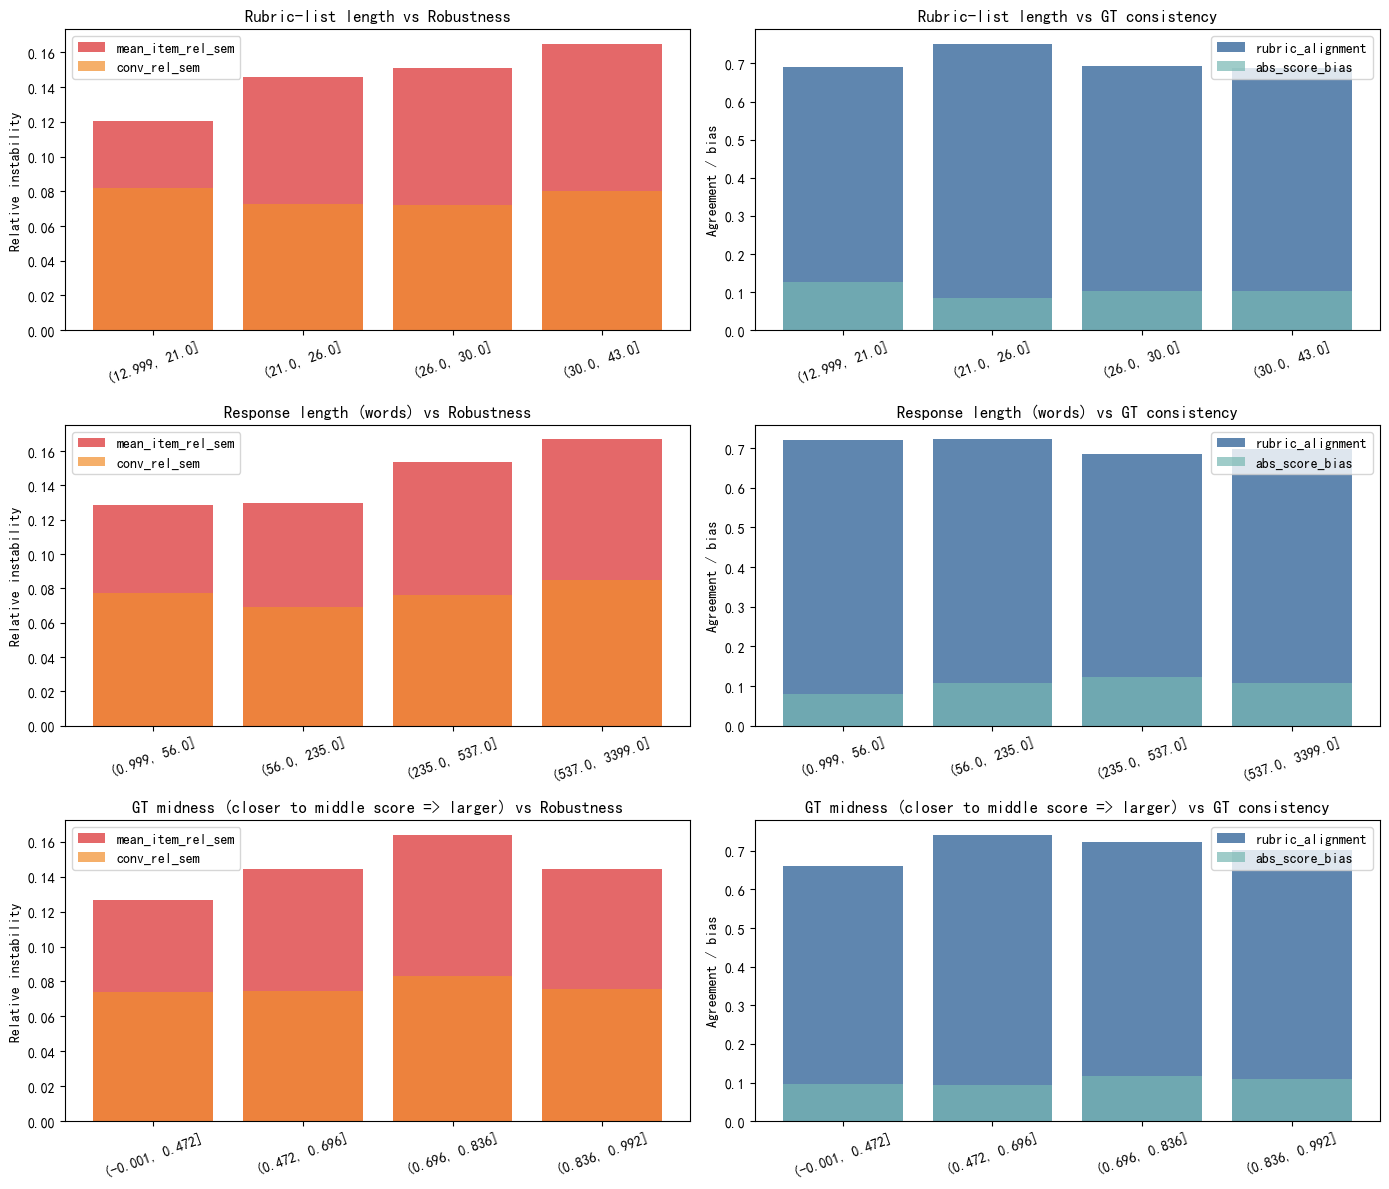

In [51]:
numeric_features = [
    'rubric_list_len',
    'total_points',
    'prompt_words',
    'response_words',
    'gt_norm_score',
    'gt_midness'
]

def summarize_factor_correlations(df, features, targets):
    rows = []
    for judge_name, df_judge in [('ALL', df)] + [(judge, df[df['judge_model'] == judge]) for judge in sorted(df['judge_model'].unique())]:
        for feature in features:
            for target in targets:
                tmp = df_judge[[feature, target]].dropna()
                if len(tmp) < 8:
                    continue
                rho = _safe_spearman(tmp[feature].values, tmp[target].values)
                rows.append({
                    'judge_model': judge_name,
                    'feature': feature,
                    'target': target,
                    'rho': rho,
                    'abs_rho': abs(rho) if not np.isnan(rho) else np.nan,
                    'n': len(tmp)
                })
    return pd.DataFrame(rows)

def summarize_by_quantile(df, feature, targets, q=4):
    tmp = df[[feature] + targets].dropna().copy()
    q = min(q, tmp[feature].nunique())
    if q < 2:
        return None
    tmp['bin'] = pd.qcut(tmp[feature], q=q, duplicates='drop')
    summary = tmp.groupby('bin')[targets].mean()
    summary['count'] = tmp.groupby('bin').size()
    return summary

corr_df = summarize_factor_correlations(df_factors, numeric_features, outcome_cols)
print('整体数据上的 Spearman 相关性（按绝对值排序）:')
display(corr_df[corr_df['judge_model'] == 'ALL'].sort_values(['target', 'abs_rho'], ascending=[True, False]))

corr_heatmap_df = corr_df[corr_df['judge_model'] == 'ALL'].pivot(
    index='feature',
    columns='target',
    values='rho'
)

plt.figure(figsize=(8, 5.5))
sns.heatmap(
    corr_heatmap_df,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-np.nanmax(np.abs(corr_heatmap_df.values)),
    vmax=np.nanmax(np.abs(corr_heatmap_df.values)),
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)
plt.title('Feature-Outcome Correlation Heatmap (ALL)')
plt.tight_layout()
plt.savefig('./figures/factor_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

plot_features = [
    ('rubric_list_len', 'Rubric-list length'),
    ('response_words', 'Response length (words)'),
    ('gt_midness', 'GT midness (closer to middle score => larger)')
]

fig, axes = plt.subplots(len(plot_features), 2, figsize=(14, 4 * len(plot_features)))
colors_left = ['#E15759', '#F28E2B']
colors_right = ['#4E79A7', '#76B7B2']

for row_idx, (feature, title) in enumerate(plot_features):
    summary = summarize_by_quantile(df_factors, feature, outcome_cols, q=4)
    if summary is None:
        continue

    labels = [str(idx) for idx in summary.index]

    axes[row_idx, 0].bar(labels, summary['mean_item_rel_sem'], color=colors_left[0], alpha=0.9, label='mean_item_rel_sem')
    axes[row_idx, 0].bar(labels, summary['conv_rel_sem'], color=colors_left[1], alpha=0.7, label='conv_rel_sem')
    axes[row_idx, 0].set_title(f'{title} vs Robustness')
    axes[row_idx, 0].set_ylabel('Relative instability')
    axes[row_idx, 0].tick_params(axis='x', rotation=20)
    axes[row_idx, 0].legend()

    axes[row_idx, 1].bar(labels, summary['rubric_alignment'], color=colors_right[0], alpha=0.9, label='rubric_alignment')
    axes[row_idx, 1].bar(labels, summary['abs_score_bias'], color=colors_right[1], alpha=0.7, label='abs_score_bias')
    axes[row_idx, 1].set_title(f'{title} vs GT consistency')
    axes[row_idx, 1].set_ylabel('Agreement / bias')
    axes[row_idx, 1].tick_params(axis='x', rotation=20)
    axes[row_idx, 1].legend()

plt.tight_layout()
plt.savefig('./figures/factor_numeric_effects.png', dpi=300, bbox_inches='tight')
plt.show()


不同任务特征标签下的平均表现:


,flag,count,sample_ratio,mean_item_rel_sem,conv_rel_sem,rubric_alignment,abs_score_bias
2,factual_grounding,6,0.02,0.040532,0.020038,0.834584,0.105120
3,safety_refusal,3,0.01,0.039803,0.015929,0.768232,0.079140
0,translation_or_rewrite,21,0.07,0.034652,0.021277,0.658974,0.124268
1,reasoning_math,3,0.01,0.023096,0.013768,0.751946,0.087354


主任务类型上的聚合结果（仅保留样本数 >= 5 的类别）:


,primary_task,sample_count,mean_item_rel_sem,conv_rel_sem,rubric_alignment,abs_score_bias
1,other_general,270,0.042339,0.022415,0.706243,0.105889
0,factual_grounding,6,0.040532,0.020038,0.834584,0.105120
3,translation_or_rewrite,21,0.034652,0.021277,0.658974,0.124268


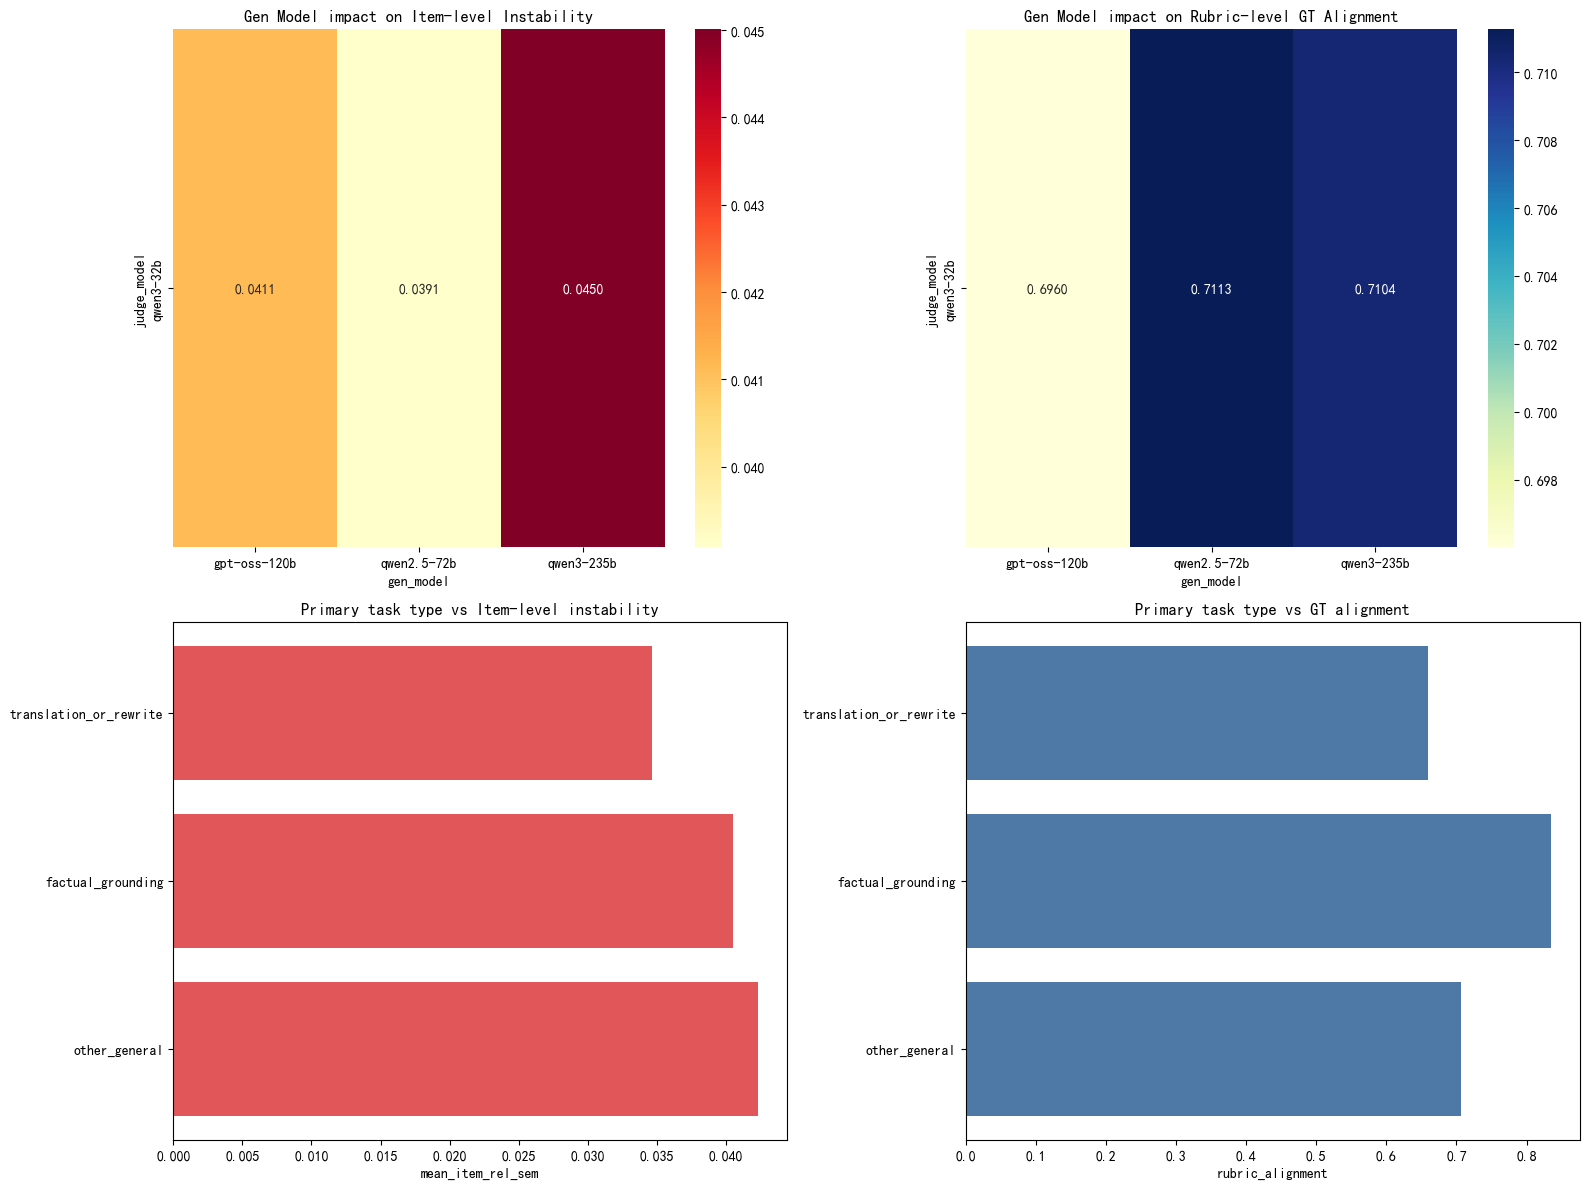

建议结合上面的相关性表、分箱图和热力图来读结果：
1. 如果 rubric_list_len / response_words 与 instability 呈正相关，说明更复杂、更长的评测对象更容易放大 Judge 波动。
2. 如果 gt_midness 越高时 alignment 越低，说明接近中间分的边界样本更难稳定评判。
3. 如果某些 task flag 或 gen_model 同时表现出更高波动和更低 alignment，它们就是后续重点扩展实验的优先候选因素。


In [54]:
def summarize_binary_flags(df, flag_columns):
    rows = []
    for flag in flag_columns:
        subset = df[df[flag]].copy()
        if len(subset) == 0:
            continue
        rows.append({
            'flag': flag,
            'count': len(subset),
            'sample_ratio': len(subset) / len(df),
            'mean_item_rel_sem': subset['mean_item_rel_sem'].mean(),
            'conv_rel_sem': subset['conv_rel_sem'].mean(),
            'rubric_alignment': subset['rubric_alignment'].mean(),
            'abs_score_bias': subset['abs_score_bias'].mean()
        })
    return pd.DataFrame(rows).sort_values('mean_item_rel_sem', ascending=False)

flag_summary = summarize_binary_flags(df_factors, flag_cols)
print('不同任务特征标签下的平均表现:')
display(flag_summary)

gen_summary = df_factors.groupby(['judge_model', 'gen_model']).agg({
    'mean_item_rel_sem': 'mean',
    'conv_rel_sem': 'mean',
    'rubric_alignment': 'mean',
    'abs_score_bias': 'mean'
})

primary_task_summary = df_factors.groupby('primary_task').agg(
    sample_count=('dialog_id', 'size'),
    mean_item_rel_sem=('mean_item_rel_sem', 'mean'),
    conv_rel_sem=('conv_rel_sem', 'mean'),
    rubric_alignment=('rubric_alignment', 'mean'),
    abs_score_bias=('abs_score_bias', 'mean')
).reset_index()
primary_task_summary = primary_task_summary[primary_task_summary['sample_count'] >= 5]
primary_task_summary = primary_task_summary.sort_values('mean_item_rel_sem', ascending=False)

print('主任务类型上的聚合结果（仅保留样本数 >= 5 的类别）:')
display(primary_task_summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.heatmap(
    gen_summary['mean_item_rel_sem'].unstack(),
    annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[0, 0]
)
axes[0, 0].set_title('Gen Model impact on Item-level Instability')

sns.heatmap(
    gen_summary['rubric_alignment'].unstack(),
    annot=True, fmt='.4f', cmap='YlGnBu', ax=axes[0, 1]
)
axes[0, 1].set_title('Gen Model impact on Rubric-level GT Alignment')

axes[1, 0].barh(primary_task_summary['primary_task'], primary_task_summary['mean_item_rel_sem'], color='#E15759')
axes[1, 0].set_title('Primary task type vs Item-level instability')
axes[1, 0].set_xlabel('mean_item_rel_sem')

axes[1, 1].barh(primary_task_summary['primary_task'], primary_task_summary['rubric_alignment'], color='#4E79A7')
axes[1, 1].set_title('Primary task type vs GT alignment')
axes[1, 1].set_xlabel('rubric_alignment')

plt.tight_layout()
plt.savefig('./figures/factor_task_and_gen_model_effects.png', dpi=300, bbox_inches='tight')
plt.show()

print('建议结合上面的相关性表、分箱图和热力图来读结果：')
print('1. 如果 rubric_list_len / response_words 与 instability 呈正相关，说明更复杂、更长的评测对象更容易放大 Judge 波动。')
print('2. 如果 gt_midness 越高时 alignment 越低，说明接近中间分的边界样本更难稳定评判。')
print('3. 如果某些 task flag 或 gen_model 同时表现出更高波动和更低 alignment，它们就是后续重点扩展实验的优先候选因素。')